# HeLoCo — Async DiLoCo with tensor-wise direction correction (cleaned)

Semantics of the outer optimizer are identical to the paper's experiments. Changes vs. the previous notebook: documentation fixed (normalized λ schedule is authoritative — paper Eq. 14 should be updated to match), streaming diagnostics (no full-model flattens, ~GBs less RAM), CPU-side dispatch snapshots, lazy toy datasets, corrected entry point (labels, Table-3 learning rates, configurable `WORKER_PACES`), portable paths. All function/class signatures unchanged; new constructor kwargs are optional.

In [1]:
"""
HeLoCo — Asynchronous DiLoCo with tensor-wise direction correction.

Cleaned reference implementation. Semantics of the outer optimizer are
IDENTICAL to the version used for the paper's experiments; changes are:

  * Documentation fixed: lambda uses the *normalized* schedule
        lam = min(k_dir * (cos_ok - c)/(cos_ok - cos_bad) * conf, 1)
    which is continuous at the cos_ok boundary (the paper's Eq. 14 form
    "1 - c" is discontinuous there and should be updated to this).
  * Diagnostics no longer materialize full flattened parameter vectors
    (cosines/norms are streamed tensor-by-tensor; recent-update similarity
    uses a fixed strided subsample) -> O(GBs) less RAM, much faster syncs.
  * Dispatch snapshots are kept on CPU; per-parameter grad metadata no
    longer pins an extra full model copy on the GPU.
  * Toy datasets are built lazily (not at import time).
  * Entry point defaults to the self-contained toy setting, labels match
    what actually runs, and worker paces are configurable (WORKER_PACES).

All public function/class signatures are unchanged; new constructor
arguments are optional with behavior-preserving defaults.
"""

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import concurrent.futures as futures
import copy
import dataclasses
import gzip
import importlib
import json
import math
import os
import random
from collections import deque
from pathlib import Path
import urllib.request
from typing import Any, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.optimizer import Optimizer
from torch.utils.data import DataLoader, Dataset

In [3]:
# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------

def seeding(seed: int) -> None:
    """Pin all random sources for reproducibility."""
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
seeding(42)

In [4]:
# ---------------------------------------------------------------------------
# Global constants
# ---------------------------------------------------------------------------

EP = 0.5
CLUSTERS_PER_CLASS = 8
D = 512
NUM_CLASSES = 4
BATCHSIZE = 2
NUM_DATA = 62_800
NUM_DATA_SMALL = 6536
NUM_WORKERS = 5
NUM_DATA_SHARDS = NUM_WORKERS

DEFAULT_MODEL_NAME = "mlp"
DEFAULT_DATASET_NAME = "toy_big"
DEFAULT_TASK_TYPE = "classification"
DEFAULT_TOKENIZER_NAME = "gpt2"

SEQ_LEN = 128
GPT_EMBED_DIM = 128
GPT_NUM_HEADS = 4
GPT_NUM_LAYERS = 8
GPT_DROPOUT = 0.0
C4_EVAL_CHAR_LIMIT = 200_000
C4_TRAIN_CHAR_LIMIT = None

DEFAULT_TEXT_DATA_ROOT = "./text_data_cache"
DEFAULT_WIKITEXT_CONFIG = "wikitext-2-raw-v1"
TINY_SHAKESPEARE_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

In [5]:
# ---------------------------------------------------------------------------
# Data utilities
# ---------------------------------------------------------------------------

def make_data(N: int, clusters_per_class: int, num_classes: int):
    # Generate a mixture-of-Gaussians classification dataset.
    K = clusters_per_class * num_classes
    n_per_cluster = N // K
    n_per_class = n_per_cluster * clusters_per_class

    centres = np.random.randn(K, D)
    centres /= np.linalg.norm(centres, axis=1, keepdims=True)

    X = np.concatenate([
        EP * np.random.randn(n_per_cluster, D) + centres[k]
        for k in range(K)
    ])
    Y = np.concatenate([
        np.full(n_per_class, cls, dtype=np.int32)
        for cls in range(num_classes)
    ])
    return X, Y


def build_toy_split(N: int, clusters_per_class: int) -> dict:
    X, Y = make_data(N, clusters_per_class, NUM_CLASSES)
    all_idx = list(range(len(X)))
    random.shuffle(all_idx)
    shard_size = len(all_idx) // NUM_DATA_SHARDS
    shard_indices = [
        all_idx[i * shard_size: (i + 1) * shard_size]
        for i in range(NUM_DATA_SHARDS)
    ]
    eval_size = min(10_000, len(X))
    eval_indices = random.sample(range(len(X)), eval_size)
    return {
        "kind": "classification",
        "X": X,
        "Y": Y,
        "shard_indices": shard_indices,
        "eval_indices": eval_indices,
    }


def _text_root() -> Path:
    root = Path(DEFAULT_TEXT_DATA_ROOT).expanduser()
    root.mkdir(parents=True, exist_ok=True)
    return root


def _iter_text_records(data_path: Path):
    files = []
    if data_path.is_file():
        files = [data_path]
    elif data_path.is_dir():
        files = sorted(
            p for p in data_path.rglob("*")
            if p.is_file() and p.suffix.lower() in {".txt", ".json", ".jsonl", ".gz"}
        )
    else:
        raise FileNotFoundError(f"Text path not found: {data_path}")

    if not files:
        raise FileNotFoundError(
            "No supported text files found. Expected .txt, .json, .jsonl, or .gz files."
        )

    for file_path in files:
        opener = gzip.open if file_path.suffix.lower() == ".gz" else open
        with opener(file_path, "rt", encoding="utf-8", errors="ignore") as fh:
            if file_path.suffix.lower() == ".txt":
                text = fh.read()
                if text.strip():
                    yield text
                continue

            for line in fh:
                line = line.strip()
                if not line:
                    continue
                try:
                    obj = json.loads(line)
                except json.JSONDecodeError:
                    yield line
                    continue
                if isinstance(obj, dict):
                    text = obj.get("text") or obj.get("content") or obj.get("raw_content")
                    if text:
                        yield text
                elif isinstance(obj, str):
                    yield obj


def _ensure_min_text(train_text: str, eval_text: str, dataset_name: str) -> tuple[str, str]:
    min_required = 4 * SEQ_LEN + 1
    if len(train_text) < min_required or len(eval_text) < (SEQ_LEN + 1):
        raise ValueError(
            f"{dataset_name} text slice is too small for language modeling. "
            f"Need at least {min_required} train chars and {SEQ_LEN + 1} eval chars."
        )
    return train_text, eval_text


def _split_text_for_lm(text: str, eval_char_limit: int = C4_EVAL_CHAR_LIMIT) -> tuple[str, str]:
    text = text.strip()
    eval_text = text[:eval_char_limit]
    train_text = text[eval_char_limit:]
    return _ensure_min_text(train_text, eval_text, "Text dataset")


def load_c4_corpus(
    data_path: str,
    train_char_limit: Optional[int] = C4_TRAIN_CHAR_LIMIT,
    eval_char_limit: int = C4_EVAL_CHAR_LIMIT,
) -> tuple[str, str]:
    if not data_path:
        raise ValueError("Please set `c4_data_dir` to your local C4 path.")

    train_chunks, eval_chunks = [], []
    train_chars = eval_chars = 0
    target_train = float("inf") if train_char_limit is None else train_char_limit

    for text in _iter_text_records(Path(data_path).expanduser()):
        text = text.strip()
        if not text:
            continue

        if eval_chars < eval_char_limit:
            take = min(len(text), eval_char_limit - eval_chars)
            eval_chunks.append(text[:take])
            eval_chars += take
            text = text[take:]

        if text and train_chars < target_train:
            take = len(text) if train_char_limit is None else min(len(text), target_train - train_chars)
            train_chunks.append(text[:take])
            train_chars += take

        if eval_chars >= eval_char_limit and train_chars >= target_train:
            break

    train_text = "\n".join(train_chunks)
    eval_text = "\n".join(eval_chunks)
    return _ensure_min_text(train_text, eval_text, "C4")


def _load_local_text_dataset(data_path: str, dataset_name: str) -> tuple[str, str]:
    path = Path(data_path).expanduser()
    if path.is_file():
        text = path.read_text(encoding="utf-8", errors="ignore")
        return _split_text_for_lm(text)

    train_candidates = ["train.txt", "wiki.train.tokens", "train.jsonl", "train.jsonl.gz"]
    eval_candidates = ["valid.txt", "validation.txt", "wiki.valid.tokens", "eval.txt"]
    train_file = next((path / name for name in train_candidates if (path / name).exists()), None)
    eval_file = next((path / name for name in eval_candidates if (path / name).exists()), None)
    if train_file is not None and eval_file is not None:
        train_text = "\n".join(_iter_text_records(train_file))
        eval_text = "\n".join(_iter_text_records(eval_file))
        return _ensure_min_text(train_text, eval_text, dataset_name)

    text = "\n".join(_iter_text_records(path))
    return _split_text_for_lm(text)


def load_wikitext_corpus(data_path: Optional[str] = None) -> tuple[str, str]:
    if data_path and Path(data_path).expanduser().exists():
        return _load_local_text_dataset(data_path, "WikiText")

    if importlib.util.find_spec("datasets") is None:
        raise ImportError(
            "WikiText auto-download requires the `datasets` package, or provide a local path via `c4_data_dir`."
        )

    from datasets import load_dataset
    ds = load_dataset("wikitext", DEFAULT_WIKITEXT_CONFIG)
    train_text = "\n".join(x["text"] for x in ds["train"] if x.get("text"))
    eval_split = "validation" if "validation" in ds else "test"
    eval_text = "\n".join(x["text"] for x in ds[eval_split] if x.get("text"))
    return _ensure_min_text(train_text, eval_text, "WikiText")


def load_tiny_shakespeare_corpus(data_path: Optional[str] = None) -> tuple[str, str]:
    if data_path and Path(data_path).expanduser().exists():
        return _load_local_text_dataset(data_path, "Tiny Shakespeare")

    root = _text_root()
    local_file = root / "tiny_shakespeare.txt"
    if not local_file.exists():
        urllib.request.urlretrieve(TINY_SHAKESPEARE_URL, local_file)
    text = local_file.read_text(encoding="utf-8", errors="ignore")
    return _split_text_for_lm(text, eval_char_limit=min(100_000, len(text) // 5))


def load_text_tokenizer(tokenizer_name: str = DEFAULT_TOKENIZER_NAME):
    if importlib.util.find_spec("transformers") is not None:
        from transformers import AutoTokenizer

        tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        if tokenizer.pad_token is None and tokenizer.eos_token is not None:
            tokenizer.pad_token = tokenizer.eos_token
        tokenizer.model_max_length = int(1e30)
        return tokenizer

    if importlib.util.find_spec("tiktoken") is not None:
        import tiktoken

        encoding = tiktoken.get_encoding(tokenizer_name)

        class TiktokenWrapper:
            def __init__(self, enc, name):
                self.enc = enc
                self.name_or_path = name
                self.eos_token_id = enc.eot_token

            def encode(self, text: str, add_special_tokens: bool = False) -> list[int]:
                return self.enc.encode(text)

            def __len__(self) -> int:
                return self.enc.n_vocab

        return TiktokenWrapper(encoding, tokenizer_name)

    raise ImportError(
        "Language modeling requires a real tokenizer. Install `transformers` or `tiktoken`, then rerun the notebook."
    )


def _tokenize_text_in_chunks(tokenizer, text: str, chunk_chars: int = 512) -> list[int]:
    token_ids = []
    for para in text.splitlines():
        para = para.strip()
        if not para:
            continue
        for start in range(0, len(para), chunk_chars):
            piece = para[start: start + chunk_chars]
            if piece:
                token_ids.extend(tokenizer.encode(piece, add_special_tokens=False))
    return token_ids


def tokenize_text_corpus(train_text: str,
                         eval_text: str,
                         tokenizer_name: str = DEFAULT_TOKENIZER_NAME) -> tuple[np.ndarray, np.ndarray, int]:
    tokenizer = load_text_tokenizer(tokenizer_name)
    train_ids = _tokenize_text_in_chunks(tokenizer, train_text)
    eval_ids = _tokenize_text_in_chunks(tokenizer, eval_text)

    min_required = 4 * SEQ_LEN + 1
    if len(train_ids) < min_required or len(eval_ids) < (SEQ_LEN + 1):
        raise ValueError(
            "Tokenized text slice is too small for language modeling. "
            f"Need at least {min_required} train tokens and {SEQ_LEN + 1} eval tokens."
        )

    vocab_size = len(tokenizer)
    train_tokens = np.asarray(train_ids, dtype=np.int64)
    eval_tokens = np.asarray(eval_ids, dtype=np.int64)
    return train_tokens, eval_tokens, vocab_size


def build_lm_split_from_texts(train_text: str,
                              eval_text: str,
                              dataset_name: str,
                              tokenizer_name: str = DEFAULT_TOKENIZER_NAME) -> dict:
    train_tokens, eval_tokens, vocab_size = tokenize_text_corpus(
        train_text,
        eval_text,
        tokenizer_name=tokenizer_name,
    )

    shard_size = len(train_tokens) // NUM_DATA_SHARDS
    shard_slices = []
    for i in range(NUM_DATA_SHARDS):
        start = i * shard_size
        end = len(train_tokens) if i == NUM_DATA_SHARDS - 1 else (i + 1) * shard_size
        shard_slices.append((start, end))

    return {
        "kind": "language_modeling",
        "dataset_name": dataset_name,
        "train_tokens": train_tokens,
        "eval_tokens": eval_tokens,
        "shard_slices": shard_slices,
        "vocab_size": int(vocab_size),
        "tokenizer_name": tokenizer_name,
    }


def _resolve_multilingual_files(data_path: str | Path) -> list[Path]:
    root = Path(data_path).expanduser()
    if root.is_file():
        return [root]
    if not root.exists():
        raise FileNotFoundError(f"Text path not found: {root}")

    files = sorted(
        p for p in root.iterdir()
        if p.is_file() and p.suffix.lower() in {".txt", ".json", ".jsonl", ".gz"}
    )
    if not files:
        raise FileNotFoundError(
            f"No multilingual files found in {root}. Expected .txt, .json, .jsonl, or .gz files."
        )
    return files

def build_c4_split(data_path: str,
                   tokenizer_name: str = DEFAULT_TOKENIZER_NAME,
                   data_partition: str = "iid",
                   train_fraction: float = 1.0) -> dict:
    if not (0.0 < train_fraction <= 1.0):
        raise ValueError(f"train_fraction must be in (0, 1], got {train_fraction}")

    if data_partition == "iid":
        train_text, eval_text = load_c4_corpus(data_path)

        # For IID case: use a fraction of the training text before tokenization
        if train_fraction < 1.0:
            keep_chars = max(1, int(len(train_text) * train_fraction))
            print(
                f"[data] IID: using {keep_chars}/{len(train_text)} characters "
                f"({train_fraction * 100:.1f}%)",
                flush=True,
            )
            train_text = train_text[:keep_chars]

        return build_lm_split_from_texts(
            train_text,
            eval_text,
            "c4",
            tokenizer_name=tokenizer_name,
        )

    if data_partition != "non_iid_lang":
        raise ValueError(f"Unknown data_partition for c4: {data_partition!r}")

    files = _resolve_multilingual_files(data_path)
    if len(files) < NUM_DATA_SHARDS:
        raise ValueError(
            f"Need at least {NUM_DATA_SHARDS} language files for non_iid_lang, "
            f"found {len(files)} in {data_path}."
        )

    tokenizer = load_text_tokenizer(tokenizer_name)
    selected_files = files[:NUM_DATA_SHARDS]

    # Equal share of eval budget per language so eval is multilingual.
    per_lang_eval_limit = C4_EVAL_CHAR_LIMIT // len(selected_files)

    train_token_shards = []
    shard_names = []
    eval_chunks = []

    for file_path in selected_files:
        train_chunks = []
        lang_eval_chars = 0
        shard_names.append(file_path.stem)

        record_count = 0
        max_records_for_this_file = None

        # If train_fraction < 1.0, count records first and keep only that fraction.
        # This keeps the same fraction from each language/worker shard.
        if train_fraction < 1.0:
            total_records = sum(1 for _ in _iter_text_records(file_path))
            max_records_for_this_file = max(1, int(total_records * train_fraction))

            print(
                f"[data] {file_path.name}: using "
                f"{max_records_for_this_file}/{total_records} records "
                f"({train_fraction * 100:.1f}%)",
                flush=True,
            )

        for text in _iter_text_records(file_path):
            if max_records_for_this_file is not None and record_count >= max_records_for_this_file:
                break

            record_count += 1

            text = text.strip()
            if not text:
                continue

            # Reserve eval characters from each language first
            if lang_eval_chars < per_lang_eval_limit:
                take = min(len(text), per_lang_eval_limit - lang_eval_chars)
                eval_chunks.append(text[:take])
                lang_eval_chars += take
                text = text[take:]

            # Remaining part goes to train
            if text:
                train_chunks.append(text)

        train_text = "\n".join(train_chunks)

        if len(train_text) < (4 * SEQ_LEN + 1):
            raise ValueError(
                f"Language shard {file_path.name} is too small for LM after eval split. "
                f"Try increasing train_fraction."
            )

        train_ids = _tokenize_text_in_chunks(tokenizer, train_text)

        if len(train_ids) < (4 * SEQ_LEN + 1):
            raise ValueError(
                f"Tokenized language shard {file_path.name} is too small for LM. "
                f"Try increasing train_fraction."
            )

        train_token_shards.append(np.asarray(train_ids, dtype=np.int64))

    eval_text = "\n".join(eval_chunks)
    eval_ids = _tokenize_text_in_chunks(tokenizer, eval_text)

    if len(eval_ids) < (SEQ_LEN + 1):
        raise ValueError(
            "Multilingual eval split is too small for language modeling. "
            "Increase data size or C4_EVAL_CHAR_LIMIT."
        )

    return {
        "kind": "language_modeling",
        "dataset_name": "c4",
        "train_token_shards": train_token_shards,
        "eval_tokens": np.asarray(eval_ids, dtype=np.int64),
        "vocab_size": int(len(tokenizer)),
        "tokenizer_name": tokenizer_name,
        "shard_names": shard_names,
        "data_partition": data_partition,
        "train_fraction": train_fraction,
    }

def build_c4_split_old(data_path: str,
                   tokenizer_name: str = DEFAULT_TOKENIZER_NAME,
                   data_partition: str = "iid") -> dict:
    if data_partition == "iid":
        train_text, eval_text = load_c4_corpus(data_path)
        return build_lm_split_from_texts(train_text, eval_text, "c4", tokenizer_name=tokenizer_name)

    if data_partition != "non_iid_lang":
        raise ValueError(f"Unknown data_partition for c4: {data_partition!r}")

    files = _resolve_multilingual_files(data_path)
    if len(files) < NUM_DATA_SHARDS:
        raise ValueError(
            f"Need at least {NUM_DATA_SHARDS} language files for non_iid_lang, found {len(files)} in {data_path}."
        )

    tokenizer = load_text_tokenizer(tokenizer_name)
    selected_files = files[:NUM_DATA_SHARDS]

    # FIX: allocate an equal share of the eval budget to each language so the
    # eval set is multilingual rather than being drawn only from the first file.
    per_lang_eval_limit = C4_EVAL_CHAR_LIMIT // len(selected_files)

    train_token_shards = []
    shard_names = []
    eval_chunks = []

    for file_path in selected_files:
        train_chunks = []
        lang_eval_chars = 0          # per-language counter (fix)
        shard_names.append(file_path.stem)

        for text in _iter_text_records(file_path):
            text = text.strip()
            if not text:
                continue

            if lang_eval_chars < per_lang_eval_limit:
                take = min(len(text), per_lang_eval_limit - lang_eval_chars)
                eval_chunks.append(text[:take])
                lang_eval_chars += take
                text = text[take:]

            if text:
                train_chunks.append(text)

        train_text = "\n".join(train_chunks)
        if len(train_text) < (4 * SEQ_LEN + 1):
            raise ValueError(
                f"Language shard {file_path.name} is too small for LM after eval split."
            )

        train_ids = _tokenize_text_in_chunks(tokenizer, train_text)
        if len(train_ids) < (4 * SEQ_LEN + 1):
            raise ValueError(
                f"Tokenized language shard {file_path.name} is too small for LM."
            )
        train_token_shards.append(np.asarray(train_ids, dtype=np.int64))

    eval_text = "\n".join(eval_chunks)
    eval_ids = _tokenize_text_in_chunks(tokenizer, eval_text)
    if len(eval_ids) < (SEQ_LEN + 1):
        raise ValueError(
            "Multilingual eval split is too small for language modeling. Increase data size."
        )

    return {
        "kind": "language_modeling",
        "dataset_name": "c4",
        "train_token_shards": train_token_shards,
        "eval_tokens": np.asarray(eval_ids, dtype=np.int64),
        "vocab_size": int(len(tokenizer)),
        "tokenizer_name": tokenizer_name,
        "shard_names": shard_names,
        "data_partition": data_partition,
    }


def build_wikitext_split(data_path: Optional[str] = None,
                         tokenizer_name: str = DEFAULT_TOKENIZER_NAME) -> dict:
    train_text, eval_text = load_wikitext_corpus(data_path)
    return build_lm_split_from_texts(train_text, eval_text, "wikitext", tokenizer_name=tokenizer_name)


def build_tiny_shakespeare_split(data_path: Optional[str] = None,
                                 tokenizer_name: str = DEFAULT_TOKENIZER_NAME) -> dict:
    train_text, eval_text = load_tiny_shakespeare_corpus(data_path)
    return build_lm_split_from_texts(train_text, eval_text, "tiny_shakespeare", tokenizer_name=tokenizer_name)


# Toy splits are built lazily on first use (previously ~250 MB of synthetic
# data was generated at import time even for C4 runs).
_TOY_SPLIT_CACHE: dict = {}


def get_toy_split(name: str) -> dict:
    if name not in _TOY_SPLIT_CACHE:
        if name == "toy_big":
            _TOY_SPLIT_CACHE[name] = build_toy_split(NUM_DATA, CLUSTERS_PER_CLASS)
        elif name == "toy_small":
            _TOY_SPLIT_CACHE[name] = build_toy_split(NUM_DATA_SMALL, 1)
        else:
            raise ValueError(f"Unknown toy split: {name!r}")
    return _TOY_SPLIT_CACHE[name]

In [6]:
# ---------------------------------------------------------------------------
# Datasets
# ---------------------------------------------------------------------------

class ClassificationDataset(torch.utils.data.Dataset):
    def __init__(self, X: np.ndarray, Y: np.ndarray) -> None:
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


class LanguageModelingDataset(torch.utils.data.Dataset):
    def __init__(self, tokens: np.ndarray, seq_len: int) -> None:
        if len(tokens) <= seq_len:
            raise ValueError("Need more tokens than seq_len for language modeling.")
        self.X = torch.tensor(tokens[:-1], dtype=torch.long)
        self.Y = torch.tensor(tokens[1:], dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self) -> int:
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, idx):
        x = self.X[idx: idx + self.seq_len]
        y = self.Y[idx: idx + self.seq_len]
        return x, y

In [7]:
# ---------------------------------------------------------------------------
# Models
# ---------------------------------------------------------------------------

class Model(nn.Module):
    """Two-layer MLP: D -> hidden_size -> NUM_CLASSES."""

    def __init__(self, hidden_size: int = 65_000) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(D, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, NUM_CLASSES),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class TinyCausalSelfAttention(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, seq_len: int, dropout: float) -> None:
        super().__init__()
        if embed_dim % num_heads != 0:
            raise ValueError("embed_dim must be divisible by num_heads")
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool)).view(1, 1, seq_len, seq_len),
            persistent=False,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(~self.mask[:, :, :T, :T], float("-inf"))
        att = self.dropout(torch.softmax(att, dim=-1))
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)


class TinyTransformerBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, seq_len: int, dropout: float) -> None:
        super().__init__()
        self.ln_1 = nn.LayerNorm(embed_dim)
        self.attn = TinyCausalSelfAttention(embed_dim, num_heads, seq_len, dropout)
        self.ln_2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class TinyGPT(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        seq_len: int = SEQ_LEN,
        embed_dim: int = GPT_EMBED_DIM,
        num_heads: int = GPT_NUM_HEADS,
        num_layers: int = GPT_NUM_LAYERS,
        dropout: float = GPT_DROPOUT,
    ) -> None:
        super().__init__()
        self.seq_len = seq_len
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(seq_len, embed_dim)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TinyTransformerBlock(embed_dim, num_heads, seq_len, dropout)
            for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, T = x.shape
        if T > self.seq_len:
            raise ValueError(f"Sequence length {T} exceeds TinyGPT limit {self.seq_len}")
        pos = torch.arange(0, T, device=x.device)
        h = self.token_emb(x) + self.pos_emb(pos)[None, :, :]
        h = self.drop(h)
        for block in self.blocks:
            h = block(h)
        h = self.ln_f(h)
        return self.head(h)
    

In [8]:
# ---------------------------------------------------------------------------
# Outer optimizer 1: MomentumLookAhead (MLA)
# ---------------------------------------------------------------------------

class MomentumLookAhead(Optimizer):
    """
    Base MLA outer optimizer for Async DiLoCo.

    Expects p.grad = pseudo-gradient Δ = θ_start − θ_final.

    Update rule:
        m <- γ·m + (1−γ)·Δ
        θ <- θ − lr·(γ·m_new + Δ)

    NOTE: this optimizer performs the momentum look-ahead in the *server
    update rule only*. Look-ahead worker DISPATCH (initializing workers at
    θ − lr·γ·m) is controlled by LOOKAHEAD_DISPATCH_FAMILY below and, per
    the paper, is a HeLoCo component — the MLA baseline does not use it.
    Add "mla" to LOOKAHEAD_DISPATCH_FAMILY to ablate that choice.
    """

    def __init__(self, params, lr: float = 0.1, momentum: float = 0.9) -> None:
        if lr < 0:
            raise ValueError(f"Invalid lr: {lr}")
        if not 0.0 <= momentum < 1.0:
            raise ValueError(f"Invalid momentum: {momentum}")
        super().__init__(params, dict(lr=lr, momentum=momentum))

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr    = group["lr"]
            gamma = group["momentum"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                delta = p.grad
                state = self.state[p]
                if "m" not in state:
                    state["m"] = torch.zeros_like(p)
                m = state["m"]
                m.mul_(gamma).add_(delta, alpha=(1.0 - gamma))
                p.add_(m,     alpha=-(lr * gamma))
                p.add_(delta, alpha=-lr)

        return loss

In [9]:
# ---------------------------------------------------------------------------
# Outer optimizer 2: SmartDCMLA_v2
# ---------------------------------------------------------------------------

class SmartDCMLA_v2(Optimizer):
    """
    Layerwise direction-corrected MLA for Async DiLoCo outer optimization.

    Makes its correction decision per tensor for higher-resolution behavior
    in transformer-style models where different layers can disagree.

    Per tensor, based on cos(Δ, m):
      cos >= cos_ok            : well aligned  -> no correction, use Δ directly
      cos < 0  (and shrink)    : conflicting   -> damp only the anti-aligned
                                                  component; preserve orthogonal novelty
      cos in [0, cos_ok)       : ambiguous     -> rotate Δ toward m with
                lam = min(k_dir * (cos_ok - cos)/(cos_ok - cos_bad) * conf, 1).
                lam fades linearly to 0 as cos -> cos_ok, so the corrected
                update is CONTINUOUS across the keep/rotate boundary.
                (This normalized schedule is the authoritative one; the
                paper's Eq. 14 "1 - c" form should be updated to match.)

    Rotation preserves ||Δ||. Shrink is component-wise.

    MLA backbone (applied with the corrected delta_corr):
        m      <- μ·m + (1−μ)·delta_corr
        θ      <- θ − lr·(delta_corr + μ·m_new)
    """

    def __init__(
        self,
        params,
        lr=0.1,
        momentum=0.9,
        k_dir=1.0,
        cos_ok=0.2,
        cos_bad=-0.2,
        conf_c=3.0,
        use_shrink_when_negative=True,
        k_shrink=0.5,
        beta_max=0.5,
        eps=1e-8,
    ):
        if lr <= 0.0:
            raise ValueError(f"Invalid lr: {lr}")
        if not (0.0 <= momentum < 1.0):
            raise ValueError(f"Invalid momentum: {momentum}")
        if k_dir < 0.0:
            raise ValueError(f"Invalid k_dir: {k_dir}")
        if not (cos_bad < cos_ok):
            raise ValueError(f"Need cos_bad < cos_ok, got {cos_bad} >= {cos_ok}")
        if conf_c < 0.0:
            raise ValueError(f"Invalid conf_c: {conf_c}")
        if k_shrink < 0.0:
            raise ValueError(f"Invalid k_shrink: {k_shrink}")
        if not (0.0 <= beta_max < 1.0):
            raise ValueError(f"Invalid beta_max: {beta_max}")
        if eps <= 0.0:
            raise ValueError(f"Invalid eps: {eps}")

        defaults = dict(
            lr=lr, momentum=momentum, k_dir=k_dir,
            cos_ok=cos_ok, cos_bad=cos_bad, conf_c=conf_c,
            use_shrink_when_negative=use_shrink_when_negative,
            k_shrink=k_shrink, beta_max=beta_max, eps=eps,
        )
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr    = group["lr"]
            mu    = group["momentum"]
            k_dir = group["k_dir"]
            cos_ok  = group["cos_ok"]
            cos_bad = group["cos_bad"]
            conf_c  = group["conf_c"]
            use_shrink_when_negative = group["use_shrink_when_negative"]
            k_shrink = group["k_shrink"]
            beta_max = group["beta_max"]
            eps      = group["eps"]

            cos_values, lam_values, beta_values = [], [], []
            conf_values, correction_sizes = [], []
            active_count = total_count = 0

            for p in group["params"]:
                if p.grad is None:
                    continue

                delta = p.grad
                st = self.state[p]
                if "momentum_buffer" not in st:
                    st["momentum_buffer"] = torch.zeros_like(p.data)
                m = st["momentum_buffer"]

                dnorm = delta.norm().item()
                mnorm = m.norm().item()
                total_count += 1

                # ---- classify alignment and compute delta_corr ----
                if dnorm < eps:
                    # Gradient too small to be meaningful; pass through unchanged.
                    cos, conf, lam, beta = 1.0, 0.0, 0.0, 0.0
                    delta_corr = delta

                elif mnorm < eps:
                    # Momentum not yet built up; no reference direction to correct toward.
                    cos, conf, lam, beta = 1.0, 0.0, 0.0, 0.0
                    delta_corr = delta

                else:
                    cos  = float((torch.sum(delta * m) / (dnorm * mnorm + eps))
                                 .clamp(-1.0, 1.0).item())
                    conf = float(dnorm / (dnorm + conf_c * mnorm + eps))

                    if cos >= cos_ok:
                        # Well aligned — no correction needed.
                        lam, beta = 0.0, 0.0
                        delta_corr = delta

                    elif use_shrink_when_negative and cos < 0.0:
                        # Anti-aligned: damp only the component of Δ that opposes m.
                        # The orthogonal component (novel information) is preserved.
                        lam = 0.0
                        beta = float(min(k_shrink * (-cos) * conf, beta_max))
                        u_m = m / (mnorm + eps)
                        signed_comp = torch.sum(delta * u_m)
                        # signed_comp < 0 is guaranteed here (cos < 0 implies dot < 0),
                        # so anti_aligned always points opposite to m.
                        anti_aligned = signed_comp * u_m
                        delta_corr = delta - beta * anti_aligned

                    else:
                        # Ambiguous zone [0, cos_ok): rotate Δ toward m.
                        # FIX: use (1 - t) so correction is LARGEST when alignment is
                        # WORST (cos near 0) and fades to zero as cos approaches cos_ok.
                        t = float(
                            ((cos - cos_bad) / (cos_ok - cos_bad + eps))
                        )
                        t = max(0.0, min(t, 1.0))
                        lam  = float(min(k_dir * (1.0 - t) * conf, 1.0))
                        beta = 0.0
                        u_delta = delta / (dnorm + eps)
                        u_m     = m / (mnorm + eps)
                        u_mix   = (1.0 - lam) * u_delta + lam * u_m
                        umn     = u_mix.norm().item()
                        # Re-scale to preserve ||Δ||.
                        delta_corr = (u_mix / (umn + eps)) * dnorm if umn >= eps else delta

                # ---- diagnostics ----
                correction_ratio = (
                    float((delta_corr - delta).norm().item() / (dnorm + eps))
                    if dnorm >= eps else 0.0
                )
                if lam > 0.0 or beta > 0.0:
                    active_count += 1

                # ---- MLA backbone ----
                m.mul_(mu).add_(delta_corr, alpha=(1.0 - mu))
                p.add_(delta_corr + mu * m, alpha=-lr)

                cos_values.append(cos)
                lam_values.append(lam)
                beta_values.append(beta)
                conf_values.append(conf)
                correction_sizes.append(correction_ratio)

            if total_count == 0:
                continue

            gstate = self.state.setdefault("__global__", {})
            gstate.update(
                last_cos=float(np.mean(cos_values)),
                last_lam=float(np.mean(lam_values)),
                last_beta=float(np.mean(beta_values)),
                last_conf=float(np.mean(conf_values)),
                last_active_rate=active_count / total_count,
                last_correction_ratio=float(np.mean(correction_sizes)),
            )

        return loss

In [10]:
# ---------------------------------------------------------------------------
# LR scheduler
# ---------------------------------------------------------------------------

class CosineScheduler:
    """Cosine-decay learning rate schedule."""

    def __init__(self, optimizer, peak_lr: float, T_max: int,
                 last_epoch: int = -1, eta_min: float = 1e-6) -> None:
        self.optimizer    = optimizer
        self.peak_lr      = peak_lr
        self.eta_min      = eta_min
        self.total_epochs = T_max
        self.last_epoch   = last_epoch

    def step(self) -> None:
        self.last_epoch += 1
        progress = min(self.last_epoch / self.total_epochs, 1.0)
        lr = self.eta_min + (self.peak_lr - self.eta_min) * 0.5 * (
            1 + math.cos(math.pi * progress)
        )
        for pg in self.optimizer.param_groups:
            pg["lr"] = lr

In [11]:
# ---------------------------------------------------------------------------
# Optimizer factory
# ---------------------------------------------------------------------------

# Optimizers whose workers are DISPATCHED from the look-ahead state
# theta - lr*gamma*m (paper Eq. 5). Per the paper this is a HeLoCo
# component; add "mla" here only for ablation studies.
LOOKAHEAD_DISPATCH_FAMILY = {"sdcmla_v2"}
_DCMLA_FAMILY = LOOKAHEAD_DISPATCH_FAMILY  # backwards-compatible alias

_OPTIMIZER_MAP = {
    "adamw":         torch.optim.AdamW,
    "sgd":           torch.optim.SGD,
    "sgd_momentum":  torch.optim.SGD,
    "nesterov":      torch.optim.SGD,
    "mla":           MomentumLookAhead,
    "sdcmla_v2":     SmartDCMLA_v2,
}


def get_optimizer(params, name: str, kwargs: dict):
    if name not in _OPTIMIZER_MAP:
        raise ValueError(
            f"Unknown optimizer '{name}'. Choose from: {list(_OPTIMIZER_MAP)}"
        )
    return _OPTIMIZER_MAP[name](params, **kwargs)

In [12]:
# ---------------------------------------------------------------------------
# Vector utilities
# ---------------------------------------------------------------------------

def flatten_tensor_list(tensors: list) -> torch.Tensor:
    return torch.cat([t.detach().reshape(-1).float().cpu() for t in tensors])


def flatten_model_grads(model: nn.Module) -> Optional[torch.Tensor]:
    chunks = [
        p.grad.detach().reshape(-1).float().cpu()
        for p in model.parameters()
        if p.grad is not None
    ]
    return torch.cat(chunks) if chunks else None


def cosine_similarity(a: Optional[torch.Tensor],
                      b: Optional[torch.Tensor],
                      eps: float = 1e-12) -> float:
    if a is None or b is None:
        return float("nan")
    na, nb = torch.norm(a).item(), torch.norm(b).item()
    if na < eps or nb < eps:
        return float("nan")
    return float(torch.dot(a, b) / (na * nb + eps))


def params_l2_distance(params_a: list, params_b: list) -> float:
    # Streamed: one diff per tensor, no full-model flatten, no double compute.
    sq = 0.0
    for a, b in zip(params_a, params_b):
        d = a.detach().float().cpu() - b.detach().float().cpu()
        sq += float(torch.dot(d.reshape(-1), d.reshape(-1)).item())
    return sq ** 0.5

In [13]:
# ---------------------------------------------------------------------------
# Streaming diagnostics (no full-model flattening)
# ---------------------------------------------------------------------------

def tensor_list_sqnorm(tensors: list) -> float:
    """Sum of squared norms across a list of tensors, streamed."""
    return sum(float(torch.sum(t.detach().float() ** 2).item()) for t in tensors)


def momentum_cosine(optimizer, model: nn.Module, pseudo_gradient: list) -> float:
    """
    cos( flatten(pseudo_gradient), flatten(momentum buffers) ), computed
    tensor-by-tensor via optimizer.state keyed on the model's parameters.
    Avoids materializing either full vector; alignment between the two
    lists is by construction (same parameter objects), not by dict order.
    """
    MOMENTUM_KEYS = ("momentum_buffer", "m", "exp_avg")
    dot = na = nb = 0.0
    found = False
    for p, delta in zip(model.parameters(), pseudo_gradient):
        st = optimizer.state.get(p)
        if not isinstance(st, dict):
            continue
        buf = None
        for key in MOMENTUM_KEYS:
            if key in st:
                buf = st[key]
                break
        if buf is None:
            continue
        found = True
        d = delta.detach().float()
        m = buf.detach().float().to(d.device)
        dot += float(torch.sum(d * m).item())
        na  += float(torch.sum(d * d).item())
        nb  += float(torch.sum(m * m).item())
    if not found or na < 1e-24 or nb < 1e-24:
        return float("nan")
    return dot / (math.sqrt(na) * math.sqrt(nb) + 1e-12)


DIAG_SUBSAMPLE_TARGET = 65_536  # elements kept for recent-update cosine diagnostics


def subsample_tensor_list(tensors: list, target: int = DIAG_SUBSAMPLE_TARGET) -> torch.Tensor:
    """
    Fixed strided subsample of the (virtually) flattened tensor list.
    Deterministic for a fixed model architecture, so cosines between
    subsamples of different updates are unbiased estimates of the full
    cosine at ~1/stride of the memory. Replaces storing full 15M-102M
    element vectors in `recent_update_vecs` (which cost 1-8 GB of RAM).
    """
    total = sum(t.numel() for t in tensors)
    stride = max(1, total // max(target, 1))
    parts = [t.detach().reshape(-1)[::stride].float().cpu() for t in tensors]
    return torch.cat(parts)


def get_momentum_buffer(optimizer) -> Optional[torch.Tensor]:
    """
    Extract momentum-like buffers from optimizer state.
    Supports: SGD ('momentum_buffer'), MLA ('m'), Adam ('exp_avg'),
              SmartDCMLA_v2 / v2Tau ('momentum_buffer').
    """
    MOMENTUM_KEYS = ("momentum_buffer", "m", "exp_avg")
    chunks = []
    for state in optimizer.state_dict()["state"].values():
        if not isinstance(state, dict):
            continue
        buf = None
        for key in MOMENTUM_KEYS:
            if key in state:
                buf = state[key]
                break
        if buf is not None:
            chunks.append(buf.detach().reshape(-1).float().cpu())
    return torch.cat(chunks) if chunks else None

In [14]:
# ---------------------------------------------------------------------------
# Bookkeeping dataclasses
# ---------------------------------------------------------------------------

@dataclasses.dataclass
class WorkerState:
    worker_id: int
    device_sec_per_step: float
    data_id: Optional[int] = None
    model_id: Optional[int] = None
    num_train_steps: Optional[int] = None
    future: Optional[futures.Future] = None
    training_finished_time: float = 0.0
    start_params: Optional[list] = None
    start_server_model_id: Optional[int] = None
    device: torch.device = torch.device("cpu")

@dataclasses.dataclass
class DataShard:
    shard_id: int
    visit_times: int = 0
    local_updates: int = 0

In [15]:
# ---------------------------------------------------------------------------
# Client-side training (runs in a thread)
# ---------------------------------------------------------------------------

def compute_loss(
    model: nn.Module,
    data: torch.Tensor,
    target: torch.Tensor,
    task_type: str,
) -> tuple[torch.Tensor, torch.Tensor]:
    logits = model(data)
    if task_type == "classification":
        loss = nn.CrossEntropyLoss()(logits, target)
    elif task_type == "language_modeling":
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), target.reshape(-1))
    else:
        raise ValueError(f"Unknown task_type: {task_type!r}")
    return logits, loss


def make_training_batch(dataset, indices: np.ndarray) -> tuple[torch.Tensor, torch.Tensor]:
    if isinstance(dataset, ClassificationDataset):
        data = dataset.X[indices]
        target = dataset.Y[indices]
        return data, target

    batch = [dataset[int(i)] for i in indices]
    data = torch.stack([item[0] for item in batch], dim=0)
    target = torch.stack([item[1] for item in batch], dim=0)
    return data, target


def inner_loop(
    local_model: nn.Module,
    dataset,
    train_indices: np.ndarray,
    train_steps: int,
    lr_schedule: str,
    local_updates_so_far: int,
    total_updates: int,
    device,
    opt_name: str,
    opt_kwargs: dict,
    task_type: str = DEFAULT_TASK_TYPE,
) -> dict:
    local_model.train()
    initial_params = [p.clone().detach() for p in local_model.parameters()]

    optimizer = get_optimizer(local_model.parameters(), opt_name, opt_kwargs)

    if lr_schedule == "cosine":
        scheduler = CosineScheduler(
            optimizer,
            peak_lr=float(opt_kwargs.get("lr", 2e-4)),  # was hardcoded 2e-4
            T_max=total_updates,
            last_epoch=(local_updates_so_far - train_steps)-1,
            eta_min=1e-6,
        )
    else:
        scheduler = None

    first_loss = last_loss = None
    begin = local_updates_so_far - train_steps

    for step in range(begin, local_updates_so_far):
        indices = train_indices[step * BATCHSIZE: (step + 1) * BATCHSIZE]
        data, target = make_training_batch(dataset, indices)
        data   = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        _, loss = compute_loss(local_model, data, target, task_type)

        if first_loss is None:
            first_loss = float(loss.item())
        last_loss = float(loss.item())

        loss.backward()
        optimizer.step()
        if scheduler:
            scheduler.step()

    pseudo_gradient = [
        (init - p.detach()).clone()
        for init, p in zip(initial_params, local_model.parameters())
    ]
    pg_norm = float(torch.norm(flatten_tensor_list(pseudo_gradient)).item())

    return {
        "pseudo_gradient": pseudo_gradient,
        "pg_norm": pg_norm,
        "first_loss": first_loss,
        "last_loss": last_loss,
    }

In [16]:
# ---------------------------------------------------------------------------
# Data sampling helpers
# ---------------------------------------------------------------------------

def sample_least_visited_shard(shards: list) -> int:
    visit_counts = np.array([s.visit_times for s in shards])
    min_count    = visit_counts.min()
    candidates   = np.where(visit_counts == min_count)[0]
    return int(np.random.choice(candidates))


def assign_task_to_worker(worker: WorkerState,
                          experiment,
                          train_steps: int,
                          shard_id: Optional[int] = None) -> int:
    # FIX: accept an explicit shard_id so callers can enforce fixed shard
    # assignments (e.g. non_iid_lang) without duplicating logic here.
    if shard_id is None:
        shard_id = sample_least_visited_shard(experiment.data_shards)
    worker.data_id = shard_id
    experiment.data_shards[shard_id].visit_times += 1
    worker.num_train_steps = train_steps
    worker.training_finished_time += train_steps * worker.device_sec_per_step
    experiment.data_shards[shard_id].local_updates += train_steps
    worker.model_id = experiment.model_id
    return shard_id


def build_train_indices(dataset: Dataset, max_local_updates: int) -> np.ndarray:
    n       = len(dataset)
    repeats = max(max_local_updates * BATCHSIZE // n * 2, 1)
    parts   = []
    for _ in range(repeats):
        x = np.arange(n)
        np.random.shuffle(x)
        parts.append(x)
    return np.concatenate(parts)

In [17]:
# ---------------------------------------------------------------------------
# Base Experiment
# ---------------------------------------------------------------------------

class Experiment:
    """Shared infrastructure: datasets, server model, eval loop."""

    def __init__(
        self,
        data_mode: str = "big",
        model_hidden_size: int = 62800,
        default_inner_steps: int = 20,
        total_phases: int = 400,
        eval_every: int = 10,
        lr_schedule: str = "cosine",
        seed: int = 42,
        inner_opt_name: str = "adamw",
        outer_opt_name: str = "nesterov",
        inner_opt_kwargs: Optional[dict] = None,
        outer_opt_kwargs: Optional[dict] = None,
        verbose: bool = False,
        model_name: str = DEFAULT_MODEL_NAME,
        dataset_name: Optional[str] = None,
        c4_data_dir: Optional[str] = None,
        tokenizer_name: str = DEFAULT_TOKENIZER_NAME,
        seq_len: int = SEQ_LEN,
        gpt_config: Optional[dict] = None,
        server_device_mode: str = "cpu",
        data_partition: str = "iid",
        worker_paces: Optional[list] = None,   # seconds/step per worker; None -> all 1.0
        train_fraction: float = 1.0,           # fraction of C4 train text to use
    ) -> None:
        self.worker_paces = worker_paces
        self.train_fraction = train_fraction
        self.default_inner_steps = default_inner_steps
        self.eval_interval = default_inner_steps * NUM_WORKERS * eval_every
        self.total_phases = total_phases
        self.max_local_updates = default_inner_steps * NUM_WORKERS * total_phases
        self.max_local_updates_per_shard = default_inner_steps * total_phases

        self.inner_opt_name = inner_opt_name
        self.inner_opt_kwargs = inner_opt_kwargs or {
            "lr": 2e-4, "weight_decay": 1e-3, "betas": (0.9, 0.999)
        }
        self.outer_opt_name = outer_opt_name
        self.outer_opt_kwargs = outer_opt_kwargs or {
            "lr": 0.1, "nesterov": True, "momentum": 0.9
        }

        if dataset_name is None:
            dataset_name = "toy_small" if data_mode == "small" else "toy_big"

        self.lr_schedule = lr_schedule
        self.model_hidden_size = model_hidden_size
        self.data_mode = data_mode
        self.seed = seed
        self.verbose = verbose
        self.model_name = model_name
        self.dataset_name = dataset_name
        self.c4_data_dir = c4_data_dir
        self.tokenizer_name = tokenizer_name
        self.seq_len = seq_len
        self.gpt_config = gpt_config or {}
        self.server_device_mode = server_device_mode
        self.server_device = self._resolve_server_device(server_device_mode)
        self.data_partition = data_partition
        self.task_type = self._infer_task_type()
        self.vocab_size: Optional[int] = None

        self._validate_configuration()
        self._initialize()

    def _infer_task_type(self) -> str:
        if self.model_name == "tiny_gpt" or self.dataset_name in {"c4", "wikitext", "tiny_shakespeare"}:
            return "language_modeling"
        return "classification"

    def _validate_configuration(self) -> None:
        valid_datasets = {"toy_big", "toy_small", "c4", "wikitext", "tiny_shakespeare"}
        valid_models = {"mlp", "tiny_gpt"}
        if self.dataset_name not in valid_datasets:
            raise ValueError(f"Unknown dataset_name: {self.dataset_name!r}")
        if self.model_name not in valid_models:
            raise ValueError(f"Unknown model_name: {self.model_name!r}")
        if self.task_type == "classification" and self.model_name != "mlp":
            raise ValueError("Classification mode currently supports model_name='mlp' only.")
        if self.task_type == "language_modeling":
            if self.dataset_name not in {"c4", "wikitext", "tiny_shakespeare"} or self.model_name != "tiny_gpt":
                raise ValueError("Language-modeling mode requires model_name='tiny_gpt' and dataset_name in {'c4', 'wikitext', 'tiny_shakespeare'}.")
            if self.dataset_name == "c4" and not self.c4_data_dir:
                raise ValueError("Please set `c4_data_dir` when dataset_name='c4'.")

    def _resolve_server_device(self, mode: str) -> torch.device:
        if mode not in {"cpu", "gpu"}:
            raise ValueError(f"Unknown server_device_mode: {mode!r}")
        if mode == "gpu" and torch.cuda.is_available():
            return torch.device("cuda:0")
        return torch.device("cpu")

    def _make_split(self) -> dict:
        if self.dataset_name == "toy_big":
            return get_toy_split("toy_big")
        if self.dataset_name == "toy_small":
            return get_toy_split("toy_small")
        if self.dataset_name == "c4":
            return build_c4_split(
                self.c4_data_dir,
                tokenizer_name=self.tokenizer_name,
                data_partition=self.data_partition,
                train_fraction=self.train_fraction,
            )
        if self.dataset_name == "wikitext":
            return build_wikitext_split(self.c4_data_dir, tokenizer_name=self.tokenizer_name)
        if self.dataset_name == "tiny_shakespeare":
            return build_tiny_shakespeare_split(self.c4_data_dir, tokenizer_name=self.tokenizer_name)
        raise ValueError(f"Unknown dataset_name: {self.dataset_name!r}")

    def _build_server_model(self) -> nn.Module:
        if self.model_name == "mlp":
            return Model(hidden_size=self.model_hidden_size).to(self.server_device)
        if self.model_name == "tiny_gpt":
            if self.vocab_size is None:
                raise ValueError("vocab_size must be initialized before building TinyGPT")
            cfg = {
                "vocab_size": self.vocab_size,
                "seq_len": self.seq_len,
                "embed_dim": GPT_EMBED_DIM,
                "num_heads": GPT_NUM_HEADS,
                "num_layers": GPT_NUM_LAYERS,
                "dropout": GPT_DROPOUT,
            }
            cfg.update(self.gpt_config)
            return TinyGPT(**cfg).to(self.server_device)
        raise ValueError(f"Unknown model_name: {self.model_name!r}")

    def _prepare_batch(self, batch, device):
        data, target = batch
        return data.to(device), target.to(device)

    def _metric_label(self) -> str:
        return "accuracy" if self.task_type == "classification" else "token_acc"

    def _secondary_metric_label(self) -> Optional[str]:
        return None if self.task_type == "classification" else "perplexity"

    def _loss_to_perplexity(self, loss: float) -> float:
        return float(math.exp(min(loss, 20.0)))

    def _evaluate_batch(self, model: nn.Module, batch) -> tuple[float, float, int]:
        data, target = self._prepare_batch(batch, batch[0].device)
        logits, loss = compute_loss(model, data, target, self.task_type)
        if self.task_type == "classification":
            correct = logits.argmax(1).eq(target).sum().item()
            count = len(data)
        else:
            preds = logits.argmax(dim=-1)
            correct = preds.eq(target).sum().item()
            count = target.numel()
        return float(loss.item()), float(correct), int(count)

    def _pick_shard(self, worker: "WorkerState") -> int:
        """
        Return the shard index to assign to this worker.

        - non_iid_lang: each worker is permanently bound to the shard whose
          index matches worker.worker_id.  This enforces true data heterogeneity
          (each worker always trains on its own language).
        - iid / all other modes: pick the least-visited shard so data is covered
          as evenly as possible across all workers.
        """
        if self.data_partition == "non_iid_lang":
            return worker.worker_id % NUM_DATA_SHARDS
        return sample_least_visited_shard(self.data_shards)

    def _initialize(self) -> None:
        seeding(self.seed)
        print(f"\n[info] Starting experiment '{self.name}' ...", flush=True)

        self.model_id = 0
        self.time_now = 0.0
        self.sync_start_time = None
        self.num_total_local_updates = 0
        self.stats: list = []
        self.update_logs: list = []
        self.recent_update_vecs = deque(maxlen=20)
        self.ema_pg_norm: Optional[float] = None
        # Running EMA of server loss and per-sync improvement.
        # server_loss_improvement = loss_before - loss_after per sync.
        # Positive = global model improved; negative = degraded.
        self.server_loss_ema: Optional[float] = None
        self.server_loss_improvement_ema: Optional[float] = None

        if self.worker_paces is not None:
            if len(self.worker_paces) != NUM_WORKERS:
                raise ValueError(
                    f"worker_paces must have {NUM_WORKERS} entries, got {len(self.worker_paces)}"
                )
            step_times = [float(s) for s in self.worker_paces]
        else:
            step_times = [1.0] * NUM_WORKERS  # homogeneous default
        self.workers = []
        num_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0
        worker_gpu_ids = []
        if num_gpus <= 0:
            worker_gpu_ids = []
        elif self.server_device.type == "cuda" and num_gpus > 1:
            worker_gpu_ids = list(range(1, num_gpus))
        else:
            worker_gpu_ids = list(range(num_gpus))

        for i, s in enumerate(step_times):
            if worker_gpu_ids:
                device_id = worker_gpu_ids[i % len(worker_gpu_ids)]
                device = torch.device(f"cuda:{device_id}")
            else:
                device = torch.device("cpu")
            self.workers.append(WorkerState(i, s, device=device))

        self.worker_update_counts = {w.worker_id: 0 for w in self.workers}
        self.worker_step_counts   = {w.worker_id: 0 for w in self.workers}
        self.worker_tau_list      = {w.worker_id: [] for w in self.workers}

        split = self._make_split()
        self.vocab_size = split.get("vocab_size")
        if split["kind"] == "classification":
            eval_ds = ClassificationDataset(split["X"][split["eval_indices"]], split["Y"][split["eval_indices"]])
            shard_datasets = [
                ClassificationDataset(split["X"][idx], split["Y"][idx])
                for idx in split["shard_indices"]
            ]
        elif split["kind"] == "language_modeling":
            eval_ds = LanguageModelingDataset(split["eval_tokens"], self.seq_len)
            if "train_token_shards" in split:
                shard_datasets = [
                    LanguageModelingDataset(tokens, self.seq_len)
                    for tokens in split["train_token_shards"]
                ]
            else:
                shard_datasets = [
                    LanguageModelingDataset(split["train_tokens"][start:end], self.seq_len)
                    for start, end in split["shard_slices"]
                ]
        else:
            raise ValueError(f"Unknown split kind: {split['kind']!r}")

        self.data_shards    = [DataShard(i) for i in range(NUM_DATA_SHARDS)]
        self.shard_datasets = shard_datasets

        if self.dataset_name == "c4" and self.data_partition == "non_iid_lang":
            print("\n[info] Worker dataset assignment (fixed — non_iid_lang):")
            for worker in self.workers:
                shard_idx = worker.worker_id % NUM_DATA_SHARDS
                print(f"  worker{worker.worker_id} -> {split['shard_names'][shard_idx]}")

        self.train_indices = [
            build_train_indices(ds, self.max_local_updates_per_shard)
            for ds in shard_datasets
        ]

        self.eval_loader = DataLoader(eval_ds, batch_size=128, shuffle=False)
        probe_loader = DataLoader(eval_ds, batch_size=min(128, len(eval_ds)), shuffle=False)
        self.probe_batch = next(iter(probe_loader))

        self.thread_pool     = futures.ThreadPoolExecutor(max_workers=NUM_WORKERS)
        self.server_model    = self._build_server_model()
        self.server_optimizer = get_optimizer(
            self.server_model.parameters(),
            self.outer_opt_name,
            self.outer_opt_kwargs,
        )

    @property
    def name(self) -> str:
        return f"{self.outer_opt_name}-{self.inner_opt_name}-{self.dataset_name}-{self.model_name}"

    @property
    def finished(self) -> bool:
        return self.num_total_local_updates >= self.max_local_updates

    # @torch.no_grad()
    # def _probe_loss(self) -> float:
    #     self.server_model.eval()
    #     loss, _, _ = self._evaluate_batch(self.server_model, self.probe_batch)
    #     return loss
    
    @torch.no_grad()
    def _probe_loss(self) -> float:
        self.server_model.eval()
        # FIX: Move the probe batch to the correct device first
        batch = self._prepare_batch(self.probe_batch, self.server_device)
        loss, _, _ = self._evaluate_batch(self.server_model, batch)
        return loss

    def _probe_grads(self) -> list:
        self.server_model.train()
        self.server_optimizer.zero_grad()
        data, target = self._prepare_batch(self.probe_batch, self.server_device)
        _, loss = compute_loss(self.server_model, data, target, self.task_type)
        loss.backward()
        grads = [
            p.grad.detach().clone() if p.grad is not None else torch.zeros_like(p)
            for p in self.server_model.parameters()
        ]
        self.server_optimizer.zero_grad()
        return grads

    def _probe_grad_vec(self) -> Optional[torch.Tensor]:
        return flatten_tensor_list(self._probe_grads())

    def evaluate(self, eval_target: list) -> None:
        if self.num_total_local_updates < min(eval_target[0], self.max_local_updates):
            return
        eval_target[0] += self.eval_interval

        self.server_model.eval()
        total_loss = total_correct = total_count = 0
        with torch.no_grad():
            for batch in self.eval_loader:
                batch = self._prepare_batch(batch, self.server_device)
                loss, correct, count = self._evaluate_batch(self.server_model, batch)
                total_loss   += loss * count
                total_correct += correct
                total_count   += count

        loss   = total_loss / total_count
        metric = total_correct / total_count
        stat   = {
            "step":   self.num_total_local_updates,
            "loss":   float(loss),
            "metric": float(metric),
            "time":   float(self.time_now),
        }
        if self.task_type == "language_modeling":
            stat["perplexity"] = self._loss_to_perplexity(loss)
        self.stats.append(stat)

        if self.verbose:
            msg = (
                f"[info] step {self.num_total_local_updates:6d} | "
                f"time {self.time_now:10.2f} | {self._metric_label()} {metric:.4f} | loss {loss:.6f}"
            )
            if self.task_type == "language_modeling":
                msg += f" | perplexity {stat['perplexity']:.3f}"
            print(msg, flush=True)

    def close(self) -> None:
        futures.wait([w.future for w in self.workers if w.future and not w.future.done()])
        self.thread_pool.shutdown()
        del self.eval_loader
        del self.server_model
        del self.server_optimizer

In [18]:
# ---------------------------------------------------------------------------
# Async Experiment
# ---------------------------------------------------------------------------

class AsyncExperiment(Experiment):
    """Asynchronous DiLoCo training loop."""

    def __init__(
        self,
        sync_method: str = "vanilla",
        sync_weight_method: str = "constant",
        max_wait_time: float = 0.0,
        **kwargs,
    ) -> None:
        if sync_method not in ("vanilla", "delayed_sgd"):
            raise ValueError(f"Unknown sync_method: {sync_method!r}")

        self.sync_method       = sync_method
        self.sync_weight_method = sync_weight_method
        self.max_wait_time     = max_wait_time
        super().__init__(**kwargs)

    @property
    def name(self) -> str:
        wait = "nowait" if self.max_wait_time <= 0 else f"wait{self.max_wait_time}"
        return (
            f"async-{self.outer_opt_name}-{self.inner_opt_name}"
            f"-{self.dataset_name}-{self.model_name}"
            f"-{self.sync_method}-{self.sync_weight_method}-{wait}"
        )

    def _synchronizable(self) -> bool:
        return (self.sync_start_time is None) or (
            self.time_now - self.sync_start_time <= self.max_wait_time
        )

    def _next_sync_worker(self) -> Optional[WorkerState]:
        pending = [w for w in self.workers if w.future is not None]
        if not pending:
            return None
        fastest = min(pending, key=lambda w: w.training_finished_time)
        if (
            self.sync_start_time is not None
            and (fastest.training_finished_time - self.sync_start_time) > self.max_wait_time
        ):
            return None
        return fastest

    def _staleness_weight(self, staleness: int) -> float:
        K = len(self.workers)
        base = math.sqrt(K) / K
        if self.sync_weight_method == "constant":
            return base
        if self.sync_weight_method == "polynomial":
            return base / math.sqrt(1 + staleness)
        raise ValueError(f"Unknown sync_weight_method: {self.sync_weight_method!r}")

    def _get_momentum_like(self, state: dict) -> Optional[torch.Tensor]:
        if not isinstance(state, dict):
            return None
        for key in ("momentum_buffer", "m", "exp_avg"):
            if key in state:
                return state[key]
        return None

    def _needs_probe_signal(self) -> bool:
        # Probe-gradient signal was only consumed by the removed sdcmla_v3.
        return False

    def _dispatch_model(self) -> nn.Module:
        local_model = copy.deepcopy(self.server_model)

        if self.outer_opt_name not in LOOKAHEAD_DISPATCH_FAMILY:
            return local_model

        group = self.server_optimizer.param_groups[0]
        lr    = float(group.get("lr", 0.0))
        gamma = float(group.get("momentum", 0.0))

        if lr <= 0 or gamma <= 0:
            return local_model

        for p_local, p_server in zip(local_model.parameters(), self.server_model.parameters()):
            st = self.server_optimizer.state.get(p_server)
            if st is None:
                continue
            m = self._get_momentum_like(st)
            if m is None:
                continue
            p_local.data.add_(m, alpha=-(lr * gamma))

        return local_model

    def _vanilla_update(
        self,
        pseudo_gradient: list,
        sync_weight: float,
        worker: WorkerState,
        staleness: int,
        probe_grads: Optional[list] = None,  # kept for signature compatibility; unused
    ) -> None:
        self.server_optimizer.zero_grad()

        for p, delta in zip(self.server_model.parameters(), pseudo_gradient):
            grad             = (sync_weight * delta.detach()).clone()
            # Cheap scalar metadata only. The previous version also attached
            # grad.start_global (a full parameter snapshot moved to the GPU),
            # which pinned an extra model copy in device memory every sync
            # and was consumed by nothing in the active optimizers.
            grad.tau         = staleness
            grad.worker_id   = worker.worker_id
            grad.sync_weight = sync_weight
            p.grad = grad

        self.server_optimizer.step()

    def _delayed_sgd_update(self, pseudo_gradient: list, sync_weight: float) -> None:
        if self.model_id % NUM_WORKERS == 0:
            self.server_optimizer.zero_grad()

        for p, delta in zip(self.server_model.parameters(), pseudo_gradient):
            contrib = (sync_weight / NUM_WORKERS) * delta.detach().clone()
            p.grad  = contrib if p.grad is None else p.grad + contrib

        if (self.model_id + 1) % NUM_WORKERS == 0:
            self.server_optimizer.step()

    def synchronize(self, worker: WorkerState) -> None:
        self.sync_start_time = self.time_now if self.sync_start_time is None else self.sync_start_time

        staleness   = self.model_id - worker.model_id
        sync_weight = self._staleness_weight(staleness)

        self.worker_update_counts[worker.worker_id] += 1
        self.worker_step_counts[worker.worker_id]   += int(worker.num_train_steps)
        self.worker_tau_list[worker.worker_id].append(int(staleness))
        self.num_total_local_updates += worker.num_train_steps

        result          = worker.future.result()
        pseudo_gradient = result["pseudo_gradient"]
        pseudo_gradient = [pg.to(self.server_device) for pg in pseudo_gradient]
        pg_norm    = float(result.get("pg_norm", float("nan")))
        first_loss = float(result.get("first_loss") or float("nan"))
        last_loss  = float(result.get("last_loss") or float("nan"))

        # Streaming diagnostics: previously this flattened the full
        # pseudo-gradient AND all momentum buffers to CPU every sync
        # (2 x model-size copies per arrival). Now cosines/norms are
        # streamed per tensor and only a fixed subsample is retained.
        pg_vec_small = subsample_tensor_list(pseudo_gradient)

        if self.ema_pg_norm is None:
            self.ema_pg_norm = pg_norm
        norm_ratio = pg_norm / (self.ema_pg_norm + 1e-12)

        cos_momentum = momentum_cosine(
            self.server_optimizer, self.server_model, pseudo_gradient
        )

        cos_probe = float("nan")  # probe-gradient signal removed with sdcmla_v3

        if worker.start_params is not None:
            model_displacement = params_l2_distance(
                list(self.server_model.parameters()), worker.start_params
            )
        else:
            model_displacement = float("nan")

        if self.recent_update_vecs:
            sims = [cosine_similarity(pg_vec_small, v) for v in self.recent_update_vecs]
            sims = [s for s in sims if not math.isnan(s)]
            avg_recent_cos = float(np.mean(sims)) if sims else float("nan")
        else:
            avg_recent_cos = float("nan")

        # Always measure server loss before the update so we can track
        # whether the global model is improving regardless of optimizer.
        probe_loss_before = self._probe_loss()

        if self.sync_method == "vanilla":
            self._vanilla_update(pseudo_gradient, sync_weight, worker, staleness)
        elif self.sync_method == "delayed_sgd":
            self._delayed_sgd_update(pseudo_gradient, sync_weight)

        # Always measure server loss after the update.
        probe_loss_after = self._probe_loss()

        # Update server-loss EMAs.
        _alpha_loss = 0.1
        if self.server_loss_ema is None:
            self.server_loss_ema = probe_loss_before
        else:
            self.server_loss_ema = (1 - _alpha_loss) * self.server_loss_ema + _alpha_loss * probe_loss_after
        _improvement = probe_loss_before - probe_loss_after
        if self.server_loss_improvement_ema is None:
            self.server_loss_improvement_ema = _improvement
        else:
            self.server_loss_improvement_ema = (1 - _alpha_loss) * self.server_loss_improvement_ema + _alpha_loss * _improvement

        opt_diag = self.server_optimizer.state.get("__global__", {})

        self.update_logs.append({
            "method":                   self.outer_opt_name,
            "server_model_id":          self.model_id,
            "num_total_local_updates":  self.num_total_local_updates,
            "time_now":                 self.time_now,
            "worker_id":                worker.worker_id,
            "worker_model_id":          worker.model_id,
            "tau":                      staleness,
            "local_steps":              int(worker.num_train_steps),
            "sync_weight":              float(sync_weight),
            "pg_norm":                  pg_norm,
            "norm_ratio":               float(norm_ratio),
            "cos_momentum":             float(cos_momentum),
            "cos_probe":                float(cos_probe),
            "avg_recent_cos":           float(avg_recent_cos),
            "model_displacement":       float(model_displacement),
            "local_loss_first":         first_loss,
            "local_loss_last":          last_loss,
            "probe_loss_before":        float(probe_loss_before),
            "probe_loss_after":         float(probe_loss_after),
            "probe_improvement":        float(probe_loss_before - probe_loss_after),
            "server_loss_ema":           float(self.server_loss_ema) if self.server_loss_ema is not None else float("nan"),
            "server_improvement_ema":    float(self.server_loss_improvement_ema) if self.server_loss_improvement_ema is not None else float("nan"),
            "opt_last_cos":             float(opt_diag.get("last_cos",             float("nan"))),
            "opt_last_lam":             float(opt_diag.get("last_lam",             float("nan"))),
            "opt_last_beta":            float(opt_diag.get("last_beta",            float("nan"))),
            "opt_last_conf":            float(opt_diag.get("last_conf",            float("nan"))),
            "opt_last_tau_mix":         float(opt_diag.get("last_tau_mix",         float("nan"))),
            "opt_last_active_rate":     float(opt_diag.get("last_active_rate",     float("nan"))),
            "opt_last_correction_ratio":float(opt_diag.get("last_correction_ratio",float("nan"))),
            "opt_last_cache_cos":       float(opt_diag.get("last_cache_cos",       float("nan"))),
            "opt_last_keep":            float(opt_diag.get("last_keep",            float("nan"))),
        })

        self.ema_pg_norm = 0.95 * self.ema_pg_norm + 0.05 * pg_norm
        self.recent_update_vecs.append(pg_vec_small)  # ~64k elems, not 15M-102M

        self.model_id += 1
        worker.future            = None
        worker.start_params      = None
        worker.start_server_model_id = None

        for w in self.workers:
            if w.future is None:
                w.training_finished_time = self.time_now

    def _dispatch_idle_workers(self) -> None:
        for worker in self.workers:
            if worker.future is not None:
                continue

            shard_id = assign_task_to_worker(
                worker, self, self.default_inner_steps,
                shard_id=self._pick_shard(worker),   # FIX: fixed shard for non_iid_lang
            )
            dispatch_mod = self._dispatch_model().to(worker.device)

            # Snapshot on CPU: only consumed by the model-displacement
            # diagnostic (params_l2_distance streams on CPU anyway).
            worker.start_params          = [p.detach().clone().cpu() for p in self.server_model.parameters()]
            worker.start_server_model_id = self.model_id

            worker.future = self.thread_pool.submit(
                inner_loop,
                dispatch_mod,
                self.shard_datasets[shard_id],
                self.train_indices[shard_id],
                self.default_inner_steps,
                self.lr_schedule,
                self.data_shards[shard_id].local_updates,
                self.max_local_updates_per_shard,
                worker.device,
                self.inner_opt_name,
                self.inner_opt_kwargs,
                self.task_type,
            )

    
    def run(self, auto_close=True) -> None:
        eval_target = [0]
        self.evaluate(eval_target)
        self._dispatch_idle_workers()

        while not self.finished:
            next_worker = self._next_sync_worker()

            if next_worker is not None:
                futures.wait([next_worker.future])
                self.time_now = max(self.time_now, next_worker.training_finished_time)

            if next_worker is not None and self._synchronizable():
                self.synchronize(next_worker)
                self.evaluate(eval_target)
            else:
                self.sync_start_time = None
                self._dispatch_idle_workers()

        total = sum(self.worker_update_counts.values())
        print("\n=== Worker contribution summary ===")
        for wid in sorted(self.worker_update_counts):
            c    = self.worker_update_counts[wid]
            steps = self.worker_step_counts[wid]
            taus  = self.worker_tau_list[wid]
            spd   = self.workers[wid].device_sec_per_step
            print(
                f"  worker{wid} (speed={spd:.2f}s/step): "
                f"updates={c:4d} ({c/total*100:5.1f}%) | "
                f"local_steps={steps:6d} | "
                f"avg_tau={np.mean(taus) if taus else 0:.2f} | "
                f"max_tau={max(taus) if taus else 0}"
            )
        print("===================================\n")
        if auto_close:
            self.close()

In [19]:
# ---------------------------------------------------------------------------
# Sync Experiment
# ---------------------------------------------------------------------------

class SyncExperiment(Experiment):
    """Synchronous DiLoCo training loop with round-based aggregation."""

    def __init__(self, **kwargs) -> None:
        super().__init__(**kwargs)

    @property
    def name(self) -> str:
        return (
            f"sync-{self.outer_opt_name}-{self.inner_opt_name}"
            f"-{self.dataset_name}-{self.model_name}"
        )

    def _get_momentum_like(self, state: dict) -> Optional[torch.Tensor]:
        if not isinstance(state, dict):
            return None
        for key in ("momentum_buffer", "m", "exp_avg"):
            if key in state:
                return state[key]
        return None

    def _dispatch_model(self) -> nn.Module:
        local_model = copy.deepcopy(self.server_model)

        if self.outer_opt_name not in LOOKAHEAD_DISPATCH_FAMILY:
            return local_model

        group = self.server_optimizer.param_groups[0]
        lr    = float(group.get("lr", 0.0))
        gamma = float(group.get("momentum", 0.0))

        if lr <= 0 or gamma <= 0:
            return local_model

        for p_local, p_server in zip(local_model.parameters(), self.server_model.parameters()):
            st = self.server_optimizer.state.get(p_server)
            if st is None:
                continue
            m = self._get_momentum_like(st)
            if m is None:
                continue
            p_local.data.add_(m, alpha=-(lr * gamma))

        return local_model

    def _needs_probe_signal(self) -> bool:
        return False  # probe-gradient signal removed with sdcmla_v3

    def synchronize(self, pseudo_gradients: list[list[torch.Tensor]], workers: list[WorkerState]) -> None:
        for worker in workers:
            self.time_now = max(self.time_now, worker.training_finished_time)
            self.worker_update_counts[worker.worker_id] += 1
            self.worker_step_counts[worker.worker_id]   += int(worker.num_train_steps)
            self.worker_tau_list[worker.worker_id].append(0)
            self.num_total_local_updates += int(worker.num_train_steps)

        sync_gradient = [
            torch.stack([g.to(self.server_device) for g in grads], dim=0).mean(dim=0)
            for grads in zip(*pseudo_gradients)
        ]

        pg_norm      = math.sqrt(tensor_list_sqnorm(sync_gradient))
        pg_vec_small = subsample_tensor_list(sync_gradient)
        if self.ema_pg_norm is None:
            self.ema_pg_norm = pg_norm
        norm_ratio   = pg_norm / (self.ema_pg_norm + 1e-12)
        cos_momentum = momentum_cosine(
            self.server_optimizer, self.server_model, sync_gradient
        )
        cos_probe = float("nan")
        # Always measure server loss before the update.
        probe_loss_before = self._probe_loss()

        results = [w.future.result() for w in workers]
        first_loss = float(np.mean([r.get("first_loss", float("nan")) for r in results]))
        last_loss  = float(np.mean([r.get("last_loss",  float("nan")) for r in results]))

        if self.recent_update_vecs:
            sims = [cosine_similarity(pg_vec_small, v) for v in self.recent_update_vecs]
            sims = [s for s in sims if not math.isnan(s)]
            avg_recent_cos = float(np.mean(sims)) if sims else float("nan")
        else:
            avg_recent_cos = float("nan")

        start_params = workers[0].start_params if workers and workers[0].start_params is not None else None
        model_displacement = (
            params_l2_distance(list(self.server_model.parameters()), start_params)
            if start_params is not None else float("nan")
        )

        self.server_optimizer.zero_grad()
        for p, g in zip(self.server_model.parameters(), sync_gradient):
            grad             = g.detach().clone()
            grad.tau         = 0
            grad.worker_id   = -1
            grad.sync_weight = 1.0
            p.grad = grad
        self.server_optimizer.step()

        # Always measure server loss after the update.
        probe_loss_after = self._probe_loss()

        # Update server-loss EMAs.
        _alpha_loss = 0.1
        if self.server_loss_ema is None:
            self.server_loss_ema = probe_loss_before
        else:
            self.server_loss_ema = (1 - _alpha_loss) * self.server_loss_ema + _alpha_loss * probe_loss_after
        _improvement = probe_loss_before - probe_loss_after
        if self.server_loss_improvement_ema is None:
            self.server_loss_improvement_ema = _improvement
        else:
            self.server_loss_improvement_ema = (1 - _alpha_loss) * self.server_loss_improvement_ema + _alpha_loss * _improvement

        opt_diag = self.server_optimizer.state.get("__global__", {})
        self.update_logs.append({
            "method":                   self.outer_opt_name,
            "server_model_id":          self.model_id,
            "num_total_local_updates":  self.num_total_local_updates,
            "time_now":                 self.time_now,
            "worker_id":                -1,
            "worker_model_id":          self.model_id,
            "tau":                      0,
            "local_steps":              int(sum(w.num_train_steps for w in workers)),
            "sync_weight":              1.0,
            "pg_norm":                  pg_norm,
            "norm_ratio":               float(norm_ratio),
            "cos_momentum":             float(cos_momentum),
            "cos_probe":                float(cos_probe),
            "avg_recent_cos":           float(avg_recent_cos),
            "model_displacement":       float(model_displacement),
            "local_loss_first":         first_loss,
            "local_loss_last":          last_loss,
            "probe_loss_before":        float(probe_loss_before),
            "probe_loss_after":         float(probe_loss_after),
            "probe_improvement":        float(probe_loss_before - probe_loss_after),
            "server_loss_ema":           float(self.server_loss_ema) if self.server_loss_ema is not None else float("nan"),
            "server_improvement_ema":    float(self.server_loss_improvement_ema) if self.server_loss_improvement_ema is not None else float("nan"),
            "opt_last_cos":             float(opt_diag.get("last_cos",             float("nan"))),
            "opt_last_lam":             float(opt_diag.get("last_lam",             float("nan"))),
            "opt_last_beta":            float(opt_diag.get("last_beta",            float("nan"))),
            "opt_last_conf":            float(opt_diag.get("last_conf",            float("nan"))),
            "opt_last_tau_mix":         float(opt_diag.get("last_tau_mix",         float("nan"))),
            "opt_last_active_rate":     float(opt_diag.get("last_active_rate",     float("nan"))),
            "opt_last_correction_ratio":float(opt_diag.get("last_correction_ratio",float("nan"))),
            "opt_last_cache_cos":       float(opt_diag.get("last_cache_cos",       float("nan"))),
            "opt_last_keep":            float(opt_diag.get("last_keep",            float("nan"))),
        })

        self.ema_pg_norm = 0.95 * self.ema_pg_norm + 0.05 * pg_norm
        self.recent_update_vecs.append(pg_vec_small)
        self.model_id += 1

        for worker in self.workers:
            worker.future                = None
            worker.start_params          = None
            worker.start_server_model_id = None
            worker.training_finished_time = self.time_now

    def train(self) -> tuple:
        workers = []
        for worker in self.workers:
            shard_id = assign_task_to_worker(
                worker, self, self.default_inner_steps,
                shard_id=self._pick_shard(worker),   # FIX: fixed shard for non_iid_lang
            )
            dispatch_mod = self._dispatch_model().to(worker.device)
            worker.start_params          = [p.detach().clone().cpu() for p in self.server_model.parameters()]
            worker.start_server_model_id = self.model_id
            worker.future = self.thread_pool.submit(
                inner_loop,
                dispatch_mod,
                self.shard_datasets[shard_id],
                self.train_indices[shard_id],
                self.default_inner_steps,
                self.lr_schedule,
                self.data_shards[shard_id].local_updates,
                self.max_local_updates_per_shard,
                worker.device,
                self.inner_opt_name,
                self.inner_opt_kwargs,
                self.task_type,
            )
            workers.append(worker)

        futures.wait([w.future for w in workers])
        pseudo_gradients = [
            [pg.to(self.server_device) for pg in w.future.result()["pseudo_gradient"]]
            for w in workers
        ]
        return pseudo_gradients, workers

    def run(self, auto_close=True) -> None:
        eval_target = [0]
        self.evaluate(eval_target)

        while not self.finished:
            pseudo_gradients, workers = self.train()
            self.synchronize(pseudo_gradients, workers)
            self.evaluate(eval_target)

        total = sum(self.worker_update_counts.values())
        print("\n=== Worker contribution summary ===")
        for wid in sorted(self.worker_update_counts):
            c     = self.worker_update_counts[wid]
            steps = self.worker_step_counts[wid]
            taus  = self.worker_tau_list[wid]
            spd   = self.workers[wid].device_sec_per_step
            print(
                f"  worker{wid} (speed={spd:.2f}s/step): "
                f"updates={c:4d} ({c/total*100:5.1f}%) | "
                f"local_steps={steps:6d} | "
                f"avg_tau={np.mean(taus) if taus else 0:.2f} | "
                f"max_tau={max(taus) if taus else 0}"
            )
        print("===================================\n")
        if auto_close:
            self.close()

In [20]:
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------
 
def summarize_update_diagnostics(df: pd.DataFrame, run_name: str) -> None:
    if df.empty:
        print(f"\n=== {run_name} - diagnostics summary ===")
        print("No update logs recorded.")
        return

    def _fmt(value: float, digits: int = 3) -> str:
        return "nan" if pd.isna(value) else f"{value:.{digits}f}"

    print(f"\n=== {run_name} - diagnostics summary ===")
    print(
        "Staleness: "
        f"mean tau={_fmt(df['tau'].mean())}, "
        f"median tau={_fmt(df['tau'].median())}, "
        f"max tau={_fmt(df['tau'].max(), 0)}"
    )
    print(
        "Update quality: "
        f"mean cos(momentum)={_fmt(df['cos_momentum'].mean())}, "
        f"mean probe improvement={_fmt(df['probe_improvement'].mean())}, "
        f"mean norm ratio={_fmt(df['norm_ratio'].mean())}"
    )
    if 'opt_last_active_rate' in df.columns:
        print(
            "Optimizer activity: "
            f"active tensors={_fmt(df['opt_last_active_rate'].mean() * 100.0, 1)}%, "
            f"correction size={_fmt(df['opt_last_correction_ratio'].mean() * 100.0, 1)}%, "
            f"mean lambda={_fmt(df['opt_last_lam'].mean())}, "
            f"mean beta={_fmt(df['opt_last_beta'].mean())}"
        )
    if 'opt_last_cache_cos' in df.columns and df['opt_last_cache_cos'].notna().any():
        print(
            "Cache behavior: "
            f"mean cache cosine={_fmt(df['opt_last_cache_cos'].mean())}, "
            f"mean keep={_fmt(df['opt_last_keep'].mean())}"
        )


def _extract_stat_arrays(exp):
    if not exp.stats:
        return None
    if isinstance(exp.stats[0], dict):
        steps = np.array([row['step'] for row in exp.stats])
        losses = np.array([row['loss'] for row in exp.stats])
        times = np.array([row['time'] for row in exp.stats])
        metric_key = 'perplexity' if exp.task_type == 'language_modeling' else 'metric'
        metrics = np.array([row.get(metric_key, row['metric']) for row in exp.stats])
    else:
        steps, losses, metrics, times = map(np.stack, zip(*exp.stats))
    return steps, losses, metrics, times


def _smooth_curve(y: np.ndarray, window: int = 3) -> np.ndarray:
    if len(y) < window or window <= 1:
        return y
    kernel = np.ones(window, dtype=float) / window
    y_pad = np.pad(y, (window // 2, window - 1 - window // 2), mode='edge')
    return np.convolve(y_pad, kernel, mode='valid')


def _rolling_mean(y: np.ndarray, window: int = 5) -> np.ndarray:
    return _smooth_curve(y.astype(float), window=max(1, window))


def _set_dynamic_ylim(ax, series_list: list[np.ndarray], pad_frac: float = 0.08) -> None:
    cleaned = []
    for arr in series_list:
        if arr is None:
            continue
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size:
            cleaned.append(arr)
    if not cleaned:
        return
    vals = np.concatenate(cleaned)
    lo = float(np.min(vals))
    hi = float(np.max(vals))
    if hi <= lo:
        span = max(abs(lo), 1.0)
        ax.set_ylim(lo - 0.1 * span, hi + 0.1 * span)
        return
    pad = pad_frac * (hi - lo)
    ax.set_ylim(lo - pad, hi + pad)


def plot_results(
    experiments: list,
    names: Optional[list] = None,
    smooth_window: int = 3,
    zoom_start: Optional[int] = None,
    zoom_fraction: float = 0.2,
) -> None:
    fig, axes = plt.subplots(2, 4, figsize=(18, 7.2))
    colors = [f"C{i}" for i in range(10)] * 5
    markers = ['o', 's', '^', 'D', 'v', 'P', 'X']

    if names is None:
        names = [exp.name for exp in experiments]

    extracted = []
    max_step = 0
    for exp in experiments:
        arrs = _extract_stat_arrays(exp)
        extracted.append(arrs)
        if arrs is not None:
            steps = arrs[0]
            if len(steps) > 0:
                max_step = max(max_step, int(np.max(steps)))

    if zoom_start is None:
        zoom_start = int(zoom_fraction * max_step)

    full_loss_series = [[] for _ in range(2)]
    full_metric_series = [[] for _ in range(2)]
    zoom_loss_series = [[] for _ in range(2)]
    zoom_metric_series = [[] for _ in range(2)]

    for i, ((exp, label), arrs) in enumerate(zip(zip(experiments, names), extracted)):
        if arrs is None:
            continue

        steps, losses, metrics, times = arrs
        losses_s = _smooth_curve(losses, smooth_window)
        metrics_s = _smooth_curve(metrics, smooth_window)

        ls = '--' if 'async' in exp.name else '-'
        marker = markers[i % len(markers)]
        style = dict(color=colors[i], linewidth=1.8, linestyle=ls, alpha=0.95)
        marker_every = max(1, len(steps) // 8)

        axes[0, 0].plot(steps, losses_s, label=label, marker=marker, markevery=marker_every, markersize=4, **style)
        axes[0, 1].plot(steps, metrics_s, marker=marker, markevery=marker_every, markersize=4, **style)
        axes[0, 2].plot(times, losses_s, marker=marker, markevery=marker_every, markersize=4, **style)
        axes[0, 3].plot(times, metrics_s, marker=marker, markevery=marker_every, markersize=4, **style)

        full_loss_series[0].append(losses_s)
        full_loss_series[1].append(losses_s)
        full_metric_series[0].append(metrics_s)
        full_metric_series[1].append(metrics_s)

        zoom_mask = steps >= zoom_start
        if np.any(zoom_mask):
            z_steps = steps[zoom_mask]
            z_times = times[zoom_mask]
            z_losses = losses_s[zoom_mask]
            z_metrics = metrics_s[zoom_mask]

            z_marker_every = max(1, len(z_steps) // 8)

            axes[1, 0].plot(z_steps, z_losses, marker=marker, markevery=z_marker_every, markersize=4, **style)
            axes[1, 1].plot(z_steps, z_metrics, marker=marker, markevery=z_marker_every, markersize=4, **style)
            axes[1, 2].plot(z_times, z_losses, marker=marker, markevery=z_marker_every, markersize=4, **style)
            axes[1, 3].plot(z_times, z_metrics, marker=marker, markevery=z_marker_every, markersize=4, **style)

            zoom_loss_series[0].append(z_losses)
            zoom_loss_series[1].append(z_losses)
            zoom_metric_series[0].append(z_metrics)
            zoom_metric_series[1].append(z_metrics)

    axes[0, 0].legend(loc='upper left', bbox_to_anchor=(0.0, -0.18), fontsize=9, ncol=2)

    if experiments and experiments[0].task_type == 'language_modeling':
        metric_title = 'perplexity'
    else:
        metric_title = experiments[0]._metric_label() if experiments else 'metric'

    titles = [
        'Loss vs Local Steps',
        f'{metric_title} vs Local Steps',
        'Loss vs Wall-Clock',
        f'{metric_title} vs Wall-Clock',
    ]
    zoom_titles = [
        f'Loss vs Local Steps (>= {zoom_start})',
        f'{metric_title} vs Local Steps (>= {zoom_start})',
        f'Loss vs Wall-Clock (>= {zoom_start})',
        f'{metric_title} vs Wall-Clock (>= {zoom_start})',
    ]

    for ax, title in zip(axes[0], titles):
        ax.set_title(title, fontsize=13)
        ax.grid(linestyle='--', linewidth=0.35, color='lightgray')
        ax.spines[['right', 'top']].set_visible(False)

    for ax, title in zip(axes[1], zoom_titles):
        ax.set_title(title, fontsize=13)
        ax.grid(linestyle='--', linewidth=0.35, color='lightgray')
        ax.spines[['right', 'top']].set_visible(False)

    _set_dynamic_ylim(axes[0, 0], full_loss_series[0])
    _set_dynamic_ylim(axes[0, 1], full_metric_series[0])
    _set_dynamic_ylim(axes[0, 2], full_loss_series[1])
    _set_dynamic_ylim(axes[0, 3], full_metric_series[1])

    _set_dynamic_ylim(axes[1, 0], zoom_loss_series[0])
    _set_dynamic_ylim(axes[1, 1], zoom_metric_series[0])
    _set_dynamic_ylim(axes[1, 2], zoom_loss_series[1])
    _set_dynamic_ylim(axes[1, 3], zoom_metric_series[1])

    plt.tight_layout()
    plt.show()


def plot_relative_gain(experiments: list, names: Optional[list] = None, baseline_label: str = 'async-mla') -> None:
    if names is None:
        names = [exp.name for exp in experiments]

    baseline_idx = next((i for i, label in enumerate(names) if label == baseline_label), None)
    if baseline_idx is None:
        return

    baseline = experiments[baseline_idx]
    baseline_arrays = _extract_stat_arrays(baseline)
    if baseline_arrays is None:
        return
    base_steps, base_losses, base_metrics, _ = baseline_arrays

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    colors = [f"C{i}" for i in range(10)] * 5

    gain_series = [[], []]
    for i, (exp, label) in enumerate(zip(experiments, names)):
        if i == baseline_idx:
            continue
        arrs = _extract_stat_arrays(exp)
        if arrs is None:
            continue
        steps, losses, metrics, _ = arrs
        if not np.array_equal(steps, base_steps):
            continue

        loss_gain = base_losses - losses
        metric_gain = metrics - base_metrics if exp.task_type != 'language_modeling' else base_metrics - metrics
        axes[0].plot(steps, loss_gain, color=colors[i], linewidth=1.8, label=label)
        axes[1].plot(steps, metric_gain, color=colors[i], linewidth=1.8, label=label)
        axes[0].fill_between(steps, 0.0, loss_gain, color=colors[i], alpha=0.12)
        axes[1].fill_between(steps, 0.0, metric_gain, color=colors[i], alpha=0.12)
        gain_series[0].append(loss_gain)
        gain_series[1].append(metric_gain)

    metric_title = 'Perplexity Gain vs MLA' if baseline.task_type == 'language_modeling' else 'Metric Gain vs MLA'
    axes[0].axhline(0.0, color='black', linewidth=1.0, linestyle=':')
    axes[1].axhline(0.0, color='black', linewidth=1.0, linestyle=':')
    axes[0].set_title('Loss Gain vs MLA', fontsize=13)
    axes[1].set_title(metric_title, fontsize=13)
    for ax in axes:
        ax.grid(linestyle='--', linewidth=0.35, color='lightgray')
        ax.spines[['right', 'top']].set_visible(False)
        ax.set_xlabel('Local steps')
    _set_dynamic_ylim(axes[0], gain_series[0], pad_frac=0.12)
    _set_dynamic_ylim(axes[1], gain_series[1], pad_frac=0.12)
    axes[0].legend(loc='upper left', bbox_to_anchor=(0.0, -0.18), fontsize=9, ncol=2)
    plt.tight_layout()
    plt.show()


def plot_update_diagnostics(experiments: list, names: Optional[list] = None) -> None:
    if names is None:
        names = [exp.name for exp in experiments]

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    colors = [f"C{i}" for i in range(10)] * 5
    diag_series = [[] for _ in range(6)]

    for i, (exp, label) in enumerate(zip(experiments, names)):
        if not getattr(exp, 'update_logs', None):
            continue
        df = pd.DataFrame(exp.update_logs)
        if df.empty:
            continue
        x = df['num_total_local_updates'].to_numpy()
        color = colors[i]

        tau_s = _smooth_curve(df['tau'].to_numpy())
        probe_s = _smooth_curve(df['probe_improvement'].to_numpy())
        good_rate = _rolling_mean((df['probe_improvement'].to_numpy() > 0.0).astype(float), window=5) * 100.0
        direction_score = _smooth_curve((df['cos_momentum'].to_numpy() * df['probe_improvement'].to_numpy()))
        axes[0, 0].plot(x, tau_s, color=color, linewidth=1.5, label=label)
        axes[0, 1].plot(x, probe_s, color=color, linewidth=1.5)
        axes[0, 2].plot(x, good_rate, color=color, linewidth=1.5)
        axes[1, 2].plot(x, direction_score, color=color, linewidth=1.5)
        diag_series[0].append(tau_s)
        diag_series[1].append(probe_s)
        diag_series[2].append(good_rate)
        diag_series[5].append(direction_score)

        if 'opt_last_active_rate' in df.columns and df['opt_last_active_rate'].notna().any():
            active_s = _smooth_curve(100.0 * df['opt_last_active_rate'].to_numpy())
            axes[1, 0].plot(x, active_s, color=color, linewidth=1.5)
            diag_series[3].append(active_s)
        if 'opt_last_correction_ratio' in df.columns and df['opt_last_correction_ratio'].notna().any():
            corr_s = _smooth_curve(100.0 * df['opt_last_correction_ratio'].to_numpy())
            axes[1, 1].plot(x, corr_s, color=color, linewidth=1.5)
            diag_series[4].append(corr_s)

    titles = [
        'Staleness (smoothed)',
        'Probe Improvement (smoothed)',
        'Good Update Rate (%)',
        'Optimizer Active Rate (%)',
        'Correction Size (%)',
        'Direction Score (cos x improvement)',
    ]
    for ax, title in zip(axes.ravel(), titles):
        ax.set_title(title, fontsize=12)
        ax.grid(linestyle='--', linewidth=0.3, color='lightgray')
        ax.spines[['right', 'top']].set_visible(False)
        ax.set_xlabel('Local steps')
    axes[0, 1].axhline(0.0, color='black', linewidth=1.0, linestyle=':')
    axes[1, 2].axhline(0.0, color='black', linewidth=1.0, linestyle=':')
    for ax, series in zip(axes.ravel(), diag_series):
        _set_dynamic_ylim(ax, series, pad_frac=0.12)

    axes[0, 0].legend(loc='upper left', bbox_to_anchor=(0.0, -0.18), fontsize=9, ncol=2)
    plt.tight_layout()
    plt.show()



from pathlib import Path
from datetime import datetime
import json
import pandas as pd


def export_run_bundle(exp, save_root="saved_runs", run_label=None):
    """
    Export one experiment run:
        saved_runs/<timestamp>_<run_label>/
            metadata.json
            stats.csv
            update_logs.csv
            worker_logs.csv

    Does NOT change training logic — only saves already-collected logs.
    """
    save_root = Path(save_root)
    save_root.mkdir(parents=True, exist_ok=True)

    if run_label is None:
        run_label = exp.outer_opt_name

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir   = save_root / f"{timestamp}_{run_label}"
    run_dir.mkdir(parents=True, exist_ok=True)

    # 1) update_logs.csv  — the full per-sync log
    update_df = pd.DataFrame(getattr(exp, "update_logs", []))
    update_df.to_csv(run_dir / "update_logs.csv", index=False)

    # 2) stats.csv  — per-eval checkpoint
    stats_df = pd.DataFrame(getattr(exp, "stats", []))
    stats_df.to_csv(run_dir / "stats.csv", index=False)

    # 3) worker_logs.csv  — compact per-sync view derived from update_logs
    if not update_df.empty:
        worker_df = update_df.copy()

        # local_loss_delta: how much the local model improved during training
        if "local_loss_first" in worker_df.columns and "local_loss_last" in worker_df.columns:
            worker_df["local_loss_delta"] = (
                worker_df["local_loss_last"] - worker_df["local_loss_first"]
            )
        else:
            worker_df["local_loss_delta"] = float("nan")

        # global_probe_improvement: absolute loss change on server probe batch
        if "probe_improvement" in worker_df.columns:
            worker_df["global_probe_improvement"] = worker_df["probe_improvement"]
        else:
            worker_df["global_probe_improvement"] = float("nan")

        # global_improvement_attribution: improvement weighted by this worker's
        # sync_weight, giving a per-update contribution to global improvement.
        if "probe_improvement" in worker_df.columns and "sync_weight" in worker_df.columns:
            worker_df["global_improvement_attribution"] = (
                worker_df["probe_improvement"] * worker_df["sync_weight"]
            )
        else:
            worker_df["global_improvement_attribution"] = float("nan")

        desired_cols = [
            "method",
            "server_model_id",
            "num_total_local_updates",
            "time_now",
            "worker_id",
            "worker_model_id",
            "tau",
            "local_steps",
            "local_loss_first",
            "local_loss_last",
            "local_loss_delta",
            "global_probe_improvement",
            "global_improvement_attribution",
            "server_loss_ema",
            "server_improvement_ema",
        ]
        available_cols = [c for c in desired_cols if c in worker_df.columns]
        worker_df = worker_df[available_cols].copy()
    else:
        worker_df = pd.DataFrame(columns=[
            "method", "server_model_id", "num_total_local_updates",
            "time_now", "worker_id", "worker_model_id", "tau",
            "local_steps", "local_loss_first", "local_loss_last",
            "local_loss_delta", "global_probe_improvement",
            "global_improvement_attribution",
        ])

    worker_df.to_csv(run_dir / "worker_logs.csv", index=False)

    # 4) metadata.json
    metadata = {
        "run_label":              run_label,
        "experiment_name":        getattr(exp, "name", None),
        "outer_opt_name":         getattr(exp, "outer_opt_name", None),
        "inner_opt_name":         getattr(exp, "inner_opt_name", None),
        "dataset_name":           getattr(exp, "dataset_name", None),
        "model_name":             getattr(exp, "model_name", None),
        "data_partition":         getattr(exp, "data_partition", None),
        "total_phases":           getattr(exp, "total_phases", None),
        "default_inner_steps":    getattr(exp, "default_inner_steps", None),
        "sync_method":            getattr(exp, "sync_method", None),
        "sync_weight_method":     getattr(exp, "sync_weight_method", None),
        "max_wait_time":          getattr(exp, "max_wait_time", None),
        "seed":                   getattr(exp, "seed", None),
        "num_updates_logged":     int(len(update_df)),
        "num_stats_logged":       int(len(stats_df)),
        "num_worker_logs_logged": int(len(worker_df)),
    }

    with open(run_dir / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"[saved] {run_dir}")
    return run_dir



from pathlib import Path
from datetime import datetime
import torch

def save_final_model_by_method(exp, method_name,
                               save_root="saved_models",
                               overwrite=False):
    method_dir = Path(save_root) / method_name
    method_dir.mkdir(parents=True, exist_ok=True)

    state_cpu = {
        k: v.detach().cpu()
        for k, v in exp.server_model.state_dict().items()
    }

    if overwrite:
        out_path = method_dir / "server_model.pt"
    else:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        out_path = method_dir / f"sync_server_model_{timestamp}.pt"

    torch.save(state_cpu, out_path)
    print(f"Saved model -> {out_path}")


[info] Starting experiment 'async-nesterov-adamw-c4-tiny_gpt-vanilla-constant-nowait' ...


[data] c4_de_100k_train.jsonl.gz: using 20000/100000 records (20.0%)
[data] c4_en_100k_train.jsonl.gz: using 20000/100000 records (20.0%)
[data] c4_es_100k_train.jsonl.gz: using 20000/100000 records (20.0%)
[data] c4_fr_100k_train.jsonl.gz: using 20000/100000 records (20.0%)
[data] c4_it_100k_train.jsonl.gz: using 20000/100000 records (20.0%)

[info] Worker dataset assignment (fixed — non_iid_lang):
  worker0 -> c4_de_100k_train.jsonl
  worker1 -> c4_en_100k_train.jsonl
  worker2 -> c4_es_100k_train.jsonl
  worker3 -> c4_fr_100k_train.jsonl
  worker4 -> c4_it_100k_train.jsonl
[info] step      0 | time       0.00 | token_acc 0.0000 | loss 10.985183 | perplexity 58993.551
[info] step   1000 | time     340.00 | token_acc 0.0238 | loss 8.689631 | perplexity 5940.988
[info] step   2000 | time     680.00 | token_acc 0.0266 | loss 8.410277 | perplexity 4493.006
[info] step   3000 | time    1000.00 | token_acc 0.0286 | loss 8.303038 | perplexity 4036.115
[info] step   4000 | time    1320.00 | 

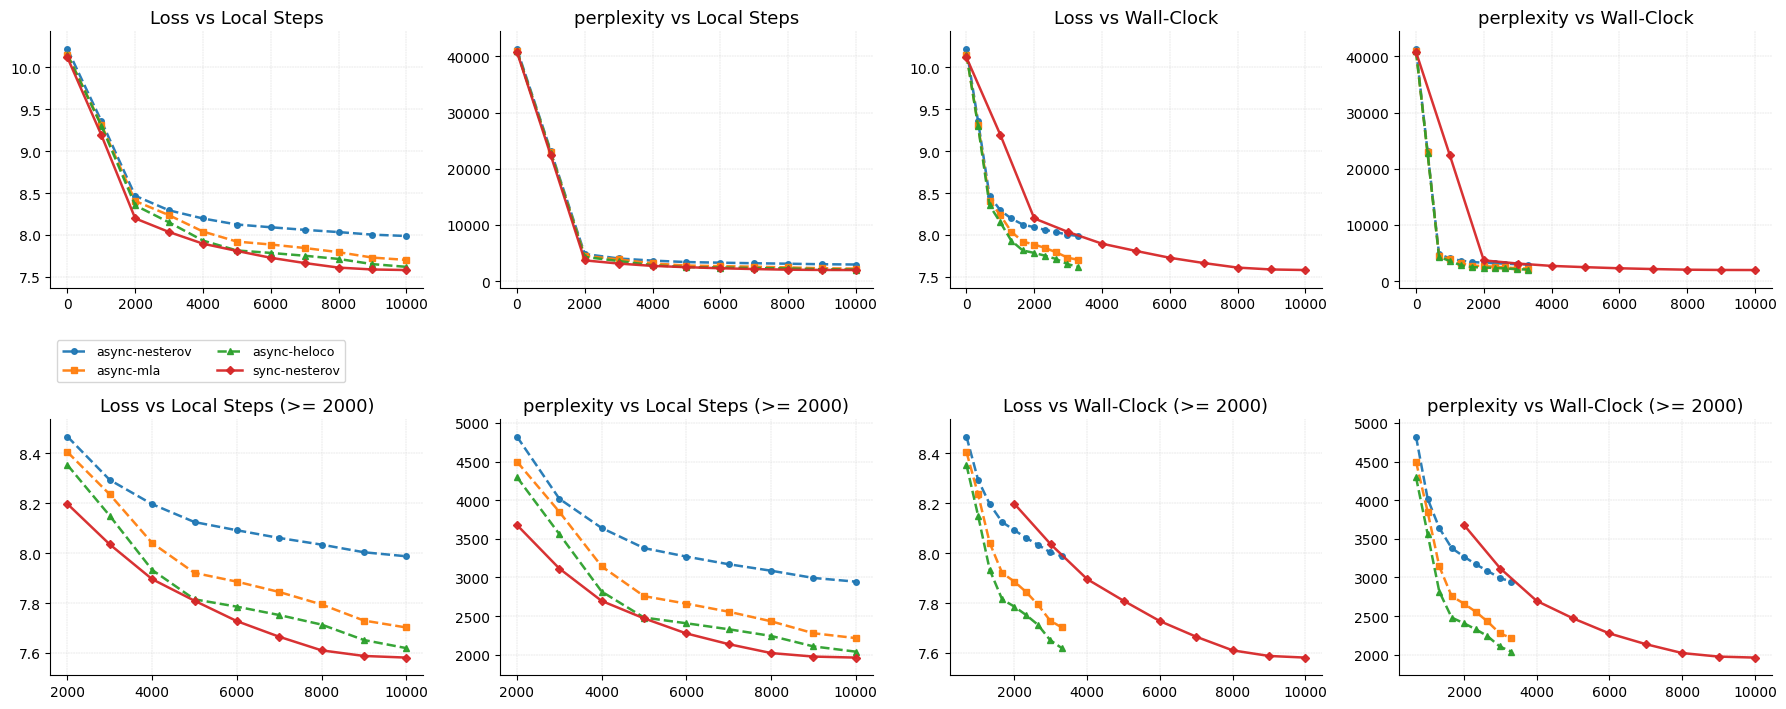

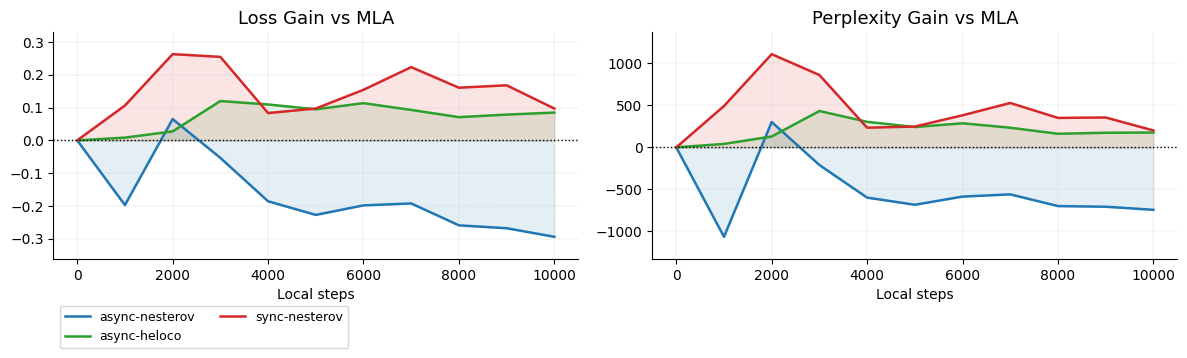

In [21]:
# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

# ---- Training length -------------------------------------------------
TOTAL_PHASES        = 100      # outer updates (per worker slot)
DEFAULT_INNER_STEPS = 20       # local steps per pseudo-gradient
SYNC_METHOD         = "vanilla"
SYNC_WEIGHT_METHOD  = "constant"   # "constant" = sqrt(K)/K ("base" in the paper)
MAX_WAIT_TIME       = 0.0          # 0 -> fully asynchronous
SERVER_DEVICE_MODE  = "gpu" if torch.cuda.is_available() else "cpu"

# ---- Dataset / model -------------------------------------------------
# Default is the SELF-CONTAINED toy setting (synthetic mixture of
# Gaussians + MLP): runs anywhere, no external data.
DATASET_NAME   = "c4"     # "toy_big" | "toy_small" | "c4" | "wikitext" | "tiny_shakespeare"
MODEL_NAME     = "tiny_gpt"         # "mlp" for toy, "tiny_gpt" for text datasets
DATA_PARTITION = "non_iid_lang"         # "iid" | "non_iid_lang" (c4 multilingual only)
TRAIN_FRACTION = 0.2
C4_DATA_DIR    = "/work/hdd/bdju/aalasif/diloco/dataset/c4/c4_multilingual_train"           # set to your local path for c4 runs:
                               # a directory with one file per language
                               # (non_iid_lang) or a single .jsonl(.gz) (iid)
TOKENIZER_NAME = "gpt2"

# ---- Worker speed heterogeneity --------------------------------------
# Seconds per local step for each of the NUM_WORKERS workers.
# Paper configurations, e.g.:
#   [1, 1, 1, 1, 1]     homogeneous
#   [1, 1, 1, 2, 2]     mild staleness
#   [1, 6, 6, 6, 6]     moderate
#   [1, 15, 15, 15, 15] extreme
WORKER_PACES = [1, 2, 3, 1, 5]

INNER_OPT_KWARGS = {
    "lr": 2e-4,
    "weight_decay": 1e-2,
    "betas": (0.9, 0.999),
}

# 15M-parameter TinyGPT (used only when MODEL_NAME == "tiny_gpt")
GPT_CONFIG = {
    "seq_len":    SEQ_LEN,
    "embed_dim":  GPT_EMBED_DIM,
    "num_heads":  GPT_NUM_HEADS,
    "num_layers": GPT_NUM_LAYERS,
    "dropout":    GPT_DROPOUT,
}

# ---- Methods (outer learning rates follow Table 3 of the paper) ------
ASYNC_RUN_CONFIGS = [
    (
        "async-nesterov",
        "nesterov",
        {"lr": 0.07, "momentum": 0.9, "nesterov": True},
    ),
    (
        "async-mla",
        "mla",
        {"lr": 0.7, "momentum": 0.9},
    ),
    (
        "async-heloco",           # SmartDCMLA_v2 == HeLoCo
        "sdcmla_v2",
        {
            "lr": 0.7, "momentum": 0.9,
            "k_dir": 1.0, "cos_ok": 0.2, "cos_bad": -0.2,
            "conf_c": 3.0, "use_shrink_when_negative": True,
            "k_shrink": 0.5, "beta_max": 0.5,
        },
    ),
]

# Sync baseline: sync learning rate (0.7, Table 3) + plain 1/K averaging.
SYNC_RUN_CONFIGS = [
    (
        "sync-nesterov",
        "nesterov",
        {"lr": 0.7, "momentum": 0.9, "nesterov": True},
    ),
]
RUN_SYNC_BASELINE = True

SAVE_ROOT        = "saved_runs"
SAVE_FINAL_MODEL = False   # enable to dump final server weights per method

common_kwargs = dict(
    verbose=True,
    total_phases=TOTAL_PHASES,
    default_inner_steps=DEFAULT_INNER_STEPS,
    seed=42,
    inner_opt_name="adamw",
    inner_opt_kwargs=INNER_OPT_KWARGS,
    dataset_name=DATASET_NAME,
    model_name=MODEL_NAME,
    c4_data_dir=C4_DATA_DIR if DATASET_NAME in {"c4", "wikitext", "tiny_shakespeare"} else None,
    tokenizer_name=TOKENIZER_NAME,
    gpt_config=GPT_CONFIG,
    server_device_mode=SERVER_DEVICE_MODE,
    data_partition=DATA_PARTITION,
    worker_paces=WORKER_PACES,
    train_fraction=TRAIN_FRACTION,
)

experiments, labels = [], []

# ---- Async experiments ------------------------------------------------
for run_name, outer_opt, outer_kwargs in ASYNC_RUN_CONFIGS:
    exp = AsyncExperiment(
        sync_method=SYNC_METHOD,
        sync_weight_method=SYNC_WEIGHT_METHOD,
        max_wait_time=MAX_WAIT_TIME,
        outer_opt_name=outer_opt,
        outer_opt_kwargs=outer_kwargs,
        **common_kwargs,
    )
    exp.run(auto_close=False)
    experiments.append(exp)
    labels.append(run_name)

    df = pd.DataFrame(exp.update_logs)
    summarize_update_diagnostics(df, run_name)
    export_run_bundle(exp, save_root=SAVE_ROOT, run_label=run_name)
    if SAVE_FINAL_MODEL:
        save_final_model_by_method(exp, method_name=run_name, overwrite=False)
    exp.close()

# ---- Sync baseline -----------------------------------------------------
if RUN_SYNC_BASELINE:
    for run_name, outer_opt, outer_kwargs in SYNC_RUN_CONFIGS:
        exp = SyncExperiment(
            outer_opt_name=outer_opt,
            outer_opt_kwargs=outer_kwargs,
            **common_kwargs,
        )
        exp.run(auto_close=False)
        experiments.append(exp)
        labels.append(run_name)

        df = pd.DataFrame(exp.update_logs)
        summarize_update_diagnostics(df, run_name)
        export_run_bundle(exp, save_root=SAVE_ROOT, run_label=run_name)
        if SAVE_FINAL_MODEL:
            save_final_model_by_method(exp, method_name=run_name, overwrite=False)
        exp.close()

plot_results(experiments, labels)
plot_relative_gain(experiments, labels)